#Overview/Purpose

The purpose of this experiment is to see the imapacts of a multi stage transfer learning process.  I am attempting to utilize a fairly limited dataset of nutrient deficient plants in an attempt to build a relatively accurate model for classifying such instances.  This is a fairly difficult classification problem due to similarities in deficiency impacts on plants as well as differences in deficiency impacts of various plant types.  Combining the sparcity of data, and the complexity of the problem creates a situation where limited success would generally be expected.

Experiments:
To start a model will be built utilizing the Oxford Flowers 102 dataset.  The model will be tested both with a basic defined Convolutional Neural Network, and then with the InceptionV3 architecture utilizing the ImageNet weight structure.  Comparing the two results will help us understand some of the value of utilizing pre-trained models to maximize the benefits of both expanded architecture as well as the pre-trained weights.

A second experiment will be performed to take the best Oxford Flowers 102 model, and utilize it on a dataset for NPK deficiencies.  The results will then be compared to a model using only the ImageNet weights in order to understand the impact of pre-training the model on the flowers dataset.

Data:
The NPK dataset was built on a combination of the [IPNI Crop Image Collection](https://www.ipni.net/article/IPNI-3231) and sourced images from various publicly available websites.
Details on the flowers 102 dataset can be seen here: https://www.tensorflow.org/datasets/catalog/oxford_flowers102

#Library Imports, and Function Prep

##Imports

In [ ]:
#!pip uninstall -y tensorflow-gpu
#!pip install tensorflow-gpu

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#!pip install -q tqdm==4.28.1
#!pip install -q -U "tensorflow-gpu==2.0.0b1"
#!pip install -q -U tensorflow_datasets
#!pip install -q -U tensorflow_hub
import warnings
warnings.filterwarnings('ignore')

from random import seed
from random import random
import time
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as sk_metrics
from sklearn.metrics import confusion_matrix
import itertools

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds
tfds.disable_progress_bar()
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)
from tensorflow import keras

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dropout, Flatten, Input, Dense

##Set Functions

In [ ]:
def resize_normalize(image,label):
  image = tf.cast(image,tf.float32)
  image = tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
  image = image / 255.0
  return image,label


def augment(image, label):
  image = tf.image.random_flip_left_right(image)
  image = tf.image.random_contrast(image, lower=0.0, upper=1.0)
  return image,label

In [ ]:
IMG_SIZE = 256
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)


In [ ]:
def splitDataset(DataSetIn):
  numpy_images = np.empty((0,IMG_SIZE,IMG_SIZE,3),'float32')#np.empty((0,3),'float32')
  numpy_labels = np.empty((0,),int)
  firstRun = True
  for images, labels in DataSetIn:
      numpy_images = np.append(numpy_images,np.expand_dims(images,axis = 0),axis = 0)
      numpy_labels = np.append(numpy_labels,np.expand_dims(labels,axis = 0),axis = 0)
  return numpy_images, numpy_labels

In [ ]:
def splitDatasetXY(x,y):
  numpy_images = np.empty((0,IMG_SIZE,IMG_SIZE,3),'float32')#np.empty((0,3),'float32')
  numpy_labels = np.empty((0,),int)
  firstRun = True
  for images in x:
      numpy_images = np.append(numpy_images,np.expand_dims(images,axis = 0),axis = 0)
      #numpy_labels = np.append(numpy_labels,np.expand_dims(labels,axis = 0),axis = 0)
  for labels in y:
      #numpy_images = np.append(numpy_images,np.expand_dims(images,axis = 0),axis = 0)
      numpy_labels = np.append(numpy_labels,np.expand_dims(labels,axis = 0),axis = 0)
  return numpy_images, numpy_labels

In [ ]:
def ShowImages(images,labels,rows, columns, seedNumber):
  #Show Images with Labels to verify
  seed(seedNumber)
  fig = plt.figure(figsize=(rows*4, columns*4))
  for x in range(1, rows*columns + 1):
    index = int(random()*len(images))
    image = images[index]
    label = labels[index]
    fig.add_subplot(rows, columns, x)
    plt.imshow(image, cmap=plt.cm.binary)
    plt.title('corresponding image label {}'.format(label))
    plt.colorbar()
    plt.grid(False)
  plt.show()


In [ ]:
def make_confusion_matrix(test_labels, predictions):
  """Compute confusion matrix and normalize."""
  confusion = sk_metrics.confusion_matrix(
    np.argmax(test_labels, axis=1), predictions)
  confusion_normalized = confusion.astype("float") / confusion.sum(axis=1)
  axis_labels = list(CLASSES.values())
  ax = sns.heatmap(
      confusion_normalized, xticklabels=axis_labels, yticklabels=axis_labels,
      cmap='Blues', annot=True, fmt='.2f', square=True)
  plt.title("Confusion matrix")
  plt.ylabel("True label")
  plt.xlabel("Predicted label")

In [ ]:
def make_confusion_matrix2(test_labels, predictions):
  """Compute confusion matrix and normalize."""
  confusion = sk_metrics.confusion_matrix(
    test_labels, predictions)
  confusion_normalized = confusion.astype("float") / confusion.sum(axis=1)
  axis_labels = list(CLASSES.values())
  ax = sns.heatmap(
      confusion_normalized, xticklabels=axis_labels, yticklabels=axis_labels,
      cmap='Blues', annot=True, fmt='.2f', square=True)
  plt.title("Confusion matrix")
  plt.ylabel("True label")
  plt.xlabel("Predicted label")

In [ ]:
def pickImages(images,labels,preds, x, seedNumber, label_names):
  #Show Images with Labels to verify
  return_images = np.empty((0,IMG_SIZE,IMG_SIZE,3),'float32')#np.empty((0,3),'float32')
  return_labels = np.empty((0,),int)
  return_preds = np.empty((0,4),'float32')
  seed(seedNumber)
  for y in range(0, len(label_names)):
    def test(x,y): return x == y
    selectArray = [idx for idx, element in enumerate(labels) if test(element,y)]
    indexArray = []
    for x in range(1, x + 1):
      index = int(random()*len(selectArray))
      while (index in indexArray):
        index = int(random()*len(selectArray))
      indexArray.append(index)
      return_images = np.append(return_images,np.expand_dims(images[selectArray[index]],axis = 0),axis = 0)
      return_labels = np.append(return_labels,np.expand_dims(labels[selectArray[index]],axis = 0),axis = 0)
      return_preds = np.append(return_preds,np.expand_dims(preds[selectArray[index]],axis = 0),axis = 0)
  return return_images, return_labels, return_preds


In [ ]:
def plot_confusion_matrix(cm, target_names=None, cmap=None, normalize=True, labels=True, title=None):
    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 9))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    thresh = cm.max() / 1.5 if normalize else cm.max() / 2

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names)
        plt.yticks(tick_marks, target_names)

    if labels:
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            if normalize:
                plt.text(j, i, "{:0.1%}".format(cm[i, j]),
                         horizontalalignment="center",
                         color="white" if cm[i, j] > thresh else "black")
            else:
                plt.text(j, i, "{:,}".format(cm[i, j]),
                         horizontalalignment="center",
                         color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted Label\n\nAccurate={:0.1%}; Misclassified={:0.1%}'.format(accuracy, misclass))
    plt.rcParams.update({'font.size': 18})
    plt.show()

In [ ]:
def plot_Images_Preds(rows, cols, images,preds,labs, class_names):
  #picked_images, picked_labels, picked_preds
  num_images = rows*cols
  plt.figure(figsize=(2*2*cols, 2*rows))
  for i in range(num_images):
    plt.subplot(rows, 2*cols, 2*i+1)
    plot_image(i, preds[i], labs, images, class_names)
    plt.subplot(rows, 2*cols, 2*i+2)
    plot_value_array(i, preds, labs)
  plt.tight_layout()
  plt.show()

In [ ]:
def plot_image(i, predictions_array, true_label, img, class_names):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_arrays, true_labels):
  predictions_array = predictions_arrays[i]
  true_label = true_labels[i]
  plt.grid(False)
  plt.xticks(range(4))
  plt.yticks([])
  thisplot = plt.bar(range(4), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)
  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

#Baseline CNN Model

Create a basic neural network of 2 9x9 convolutions with pooling layers and 2 fully connected layers at the end

##Load Data

In [ ]:
!rm -rf '/content/data/NPK/'
import zipfile
with zipfile.ZipFile("/content/gdrive/MyDrive/ML Support/HNPK.zip","r") as zip_ref:
    zip_ref.extractall("/content/data")

In [ ]:
trainDefData = tf.keras.preprocessing.image_dataset_from_directory('/content/data/HNPK/', validation_split = .1649, seed = 23, subset = 'training')
valDefData = tf.keras.preprocessing.image_dataset_from_directory('/content/data/HNPK/', validation_split = .1649, seed = 23, subset = 'validation')

Found 728 files belonging to 4 classes.
Using 608 files for training.
Found 728 files belonging to 4 classes.
Using 120 files for validation.


In [ ]:
trainDef = trainDefData.map(resize_normalize)
valDef = valDefData.map(resize_normalize)

In [ ]:
def unpackData(input_data):
  numpy_images = np.empty((0,IMG_SIZE,IMG_SIZE,3),'float32')#np.empty((0,3),'float32')
  numpy_labels = np.empty((0,),int)
  firstRun = True
  for images, labels in input_data:
    for x in images:
      numpy_images = np.append(numpy_images,np.expand_dims(x,axis = 0),axis = 0)
    for y in labels:
      numpy_labels = np.append(numpy_labels,np.expand_dims(y,axis = 0),axis = 0)

  return numpy_images, numpy_labels

In [ ]:
x,y = unpackData(trainDef)
def_train_imgs, def_train_labels = splitDatasetXY(x,y)
x,y = unpackData(valDef)
def_val_imgs, def_val_labels = splitDatasetXY(x,y)

##Create Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model

In [ ]:
base_model = models.Sequential([
  tf.keras.layers.Conv2D(256, (9, 9), activation='relu', input_shape=IMG_SHAPE),
  tf.keras.layers.MaxPooling2D(9, 9),
  tf.keras.layers.Conv2D(32, (9, 9), activation='relu'),
  tf.keras.layers.MaxPooling2D(9, 9),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(512),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(256),
  tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])


In [ ]:
adamOpt = tf.keras.optimizers.Adam(learning_rate=0.0001)

base_model.compile(optimizer=adamOpt,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
base_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 248, 248, 256)     62464     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 27, 27, 256)      0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 19, 19, 32)        663584    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 2, 2, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 512)               6

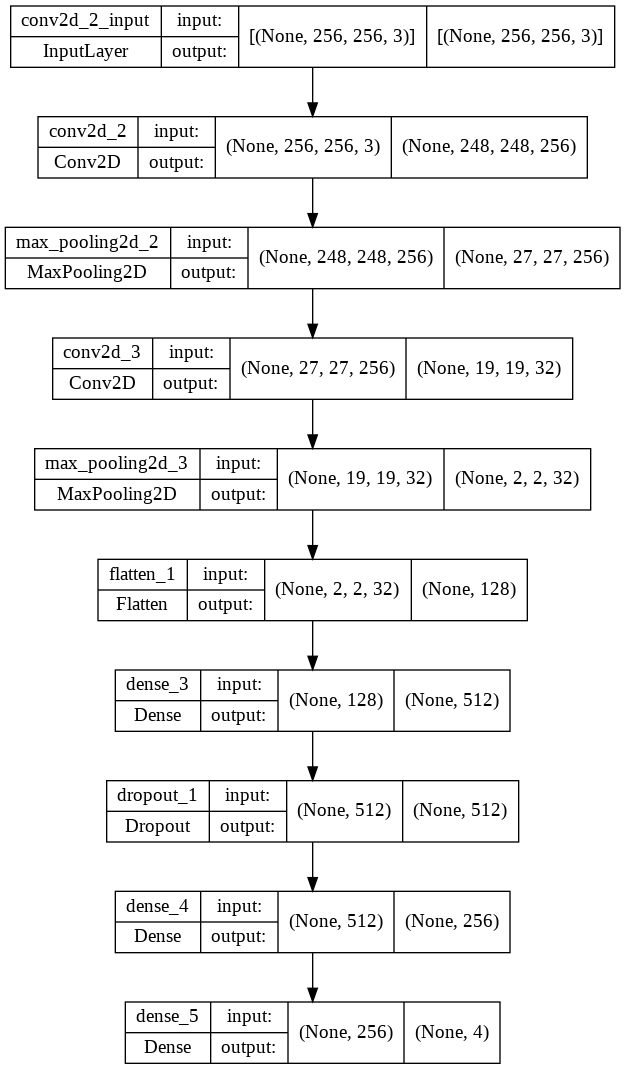

In [ ]:
plot_model(base_model, show_shapes=True, show_layer_names=True)

##Train Model

In [ ]:
history_Def = base_model.fit(def_train_imgs
                    ,def_train_labels
                    ,epochs=200
                    ,batch_size=18
                    ,validation_data=(def_val_imgs, def_val_labels)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=200),
                    tf.keras.callbacks.ModelCheckpoint('/content/gdrive/MyDrive/Backups/NPK/model_{val_accuracy:.4f}.h5', save_best_only=True,
                                        save_weights_only=False, monitor='val_accuracy')]
                   )

Epoch 1/200
 3/34 [=>............................] - ETA: 2s - loss: 1.3863 - accuracy: 0.2222

KeyboardInterrupt: ignored

In [ ]:
history_Def = base_model.fit(def_train_imgs
                    ,def_train_labels
                    ,epochs=200
                    ,batch_size=16
                    ,validation_data=(def_val_imgs, def_val_labels)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=200),
                    tf.keras.callbacks.ModelCheckpoint('/content/gdrive/MyDrive/Backups/NPK/model_{val_accuracy:.4f}.h5', save_best_only=True,
                                        save_weights_only=False, monitor='val_accuracy')]
                   )

Epoch 1/200
38/38 [==============================] - 7s 153ms/step - loss: 3.0924 - accuracy: 0.2516 - val_loss: 1.3757 - val_accuracy: 0.2750
Epoch 2/200
38/38 [==============================] - 5s 143ms/step - loss: 1.4270 - accuracy: 0.2780 - val_loss: 1.3437 - val_accuracy: 0.3333
Epoch 3/200
38/38 [==============================] - 5s 142ms/step - loss: 1.4009 - accuracy: 0.2615 - val_loss: 1.3312 - val_accuracy: 0.3500
Epoch 4/200
38/38 [==============================] - 6s 155ms/step - loss: 1.3944 - accuracy: 0.3076 - val_loss: 1.3182 - val_accuracy: 0.3750
Epoch 5/200
38/38 [==============================] - 5s 142ms/step - loss: 1.3825 - accuracy: 0.3174 - val_loss: 1.3131 - val_accuracy: 0.3833
Epoch 6/200
38/38 [==============================] - 5s 142ms/step - loss: 1.3703 - accuracy: 0.2911 - val_loss: 1.2981 - val_accuracy: 0.3917
Epoch 7/200
38/38 [==============================] - 5s 139ms/step - loss: 1.3322 - accuracy: 0.3191 - val_loss: 1.2845 - val_accuracy: 0.3583

In [ ]:
losses = history_Def.history['loss']
accs = history_Def.history['accuracy']
val_losses = history_Def.history['val_loss']
val_accs = history_Def.history['val_accuracy']
epochs = len(losses)

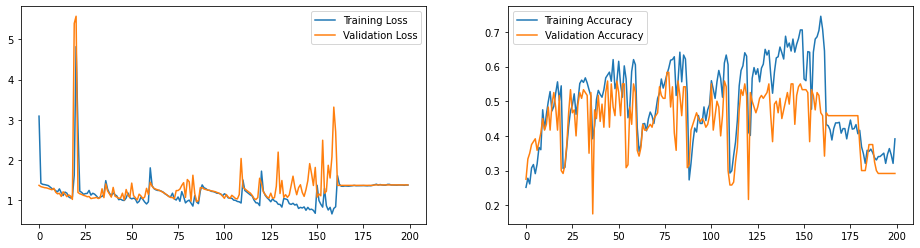

In [ ]:
plt.figure(figsize=(16, 4))
for i, metrics in enumerate(zip([losses, accs], [val_losses, val_accs], ['Loss', 'Accuracy'])):
    plt.subplot(1, 2, i + 1)
    plt.plot(range(epochs), metrics[0], label='Training {}'.format(metrics[2]))
    plt.plot(range(epochs), metrics[1], label='Validation {}'.format(metrics[2]))
    plt.legend()
plt.show()

##Model Results

In [ ]:
 base_model = tf.keras.models.load_model('/content/gdrive/MyDrive/Backups/NPK/model_0.5833.h5')

In [ ]:
Y_Pred_base = base_model.predict(def_val_imgs)
Y_test = def_val_labels.flatten()
Y_Pred_base = np.argmax(Y_Pred_base,axis=1)

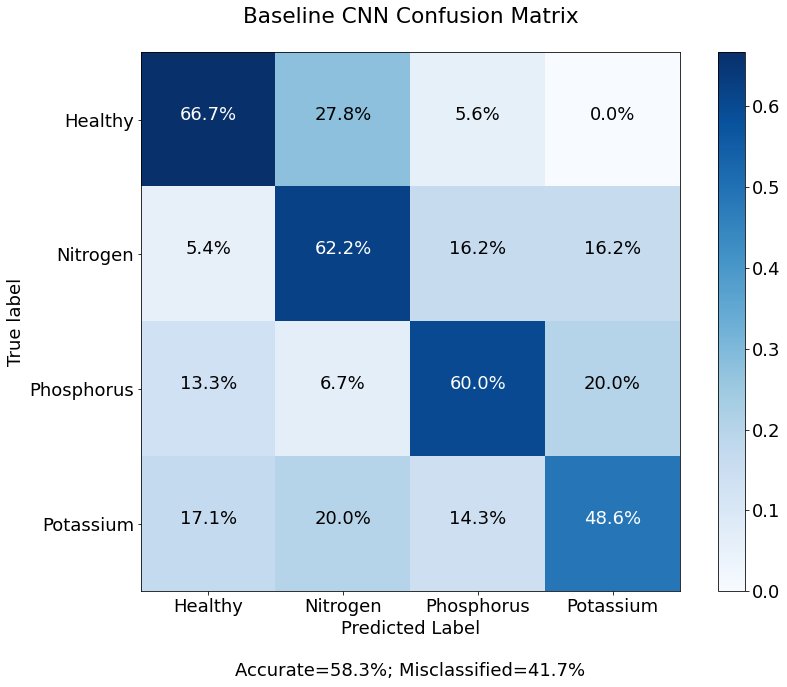

In [ ]:
plot_confusion_matrix(confusion_matrix(def_val_labels, Y_Pred_base),target_names=valDefData.class_names,title='Baseline CNN Confusion Matrix\n')

#Oxford Flowers 102 Model

##Normalize Data

In [ ]:
# TODO: Load the dataset with TensorFlow Datasets.
dataset, dataset_info = tfds.load('oxford_flowers102', with_info=True, as_supervised=True)
dataset_info
# TODO: Create a training set, a validation set and a test set.
test_set, training_set, validation_set = dataset['test'], dataset['train'], dataset['validation']

Shuffling and writing examples to /root/tensorflow_datasets/oxford_flowers102/2.1.1.incomplete4JFGQ7/oxford_flowers102-train.tfrecord
Shuffling and writing examples to /root/tensorflow_datasets/oxford_flowers102/2.1.1.incomplete4JFGQ7/oxford_flowers102-test.tfrecord
Shuffling and writing examples to /root/tensorflow_datasets/oxford_flowers102/2.1.1.incomplete4JFGQ7/oxford_flowers102-validation.tfrecord
Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


In [ ]:
print(dataset)

{'test': <PrefetchDataset shapes: ((None, None, 3), ()), types: (tf.uint8, tf.int64)>, 'train': <PrefetchDataset shapes: ((None, None, 3), ()), types: (tf.uint8, tf.int64)>, 'validation': <PrefetchDataset shapes: ((None, None, 3), ()), types: (tf.uint8, tf.int64)>}


In [ ]:
train = training_set.map(resize_normalize)
val = validation_set.map(resize_normalize)
test = test_set.map(resize_normalize)

In [ ]:
train_Image, train_Label = splitDataset(train.as_numpy_iterator())

In [ ]:
val_Image, val_Label = splitDataset(val.as_numpy_iterator())

In [ ]:
test_Image, test_Label = splitDataset(test.as_numpy_iterator())

In [ ]:
print(train_Image.shape, train_Label.shape)
print(val_Image.shape, val_Label.shape)
print(test_Image.shape, test_Label.shape)

(1020, 256, 256, 3) (1020,)
(1020, 256, 256, 3) (1020,)
(6149, 256, 256, 3) (6149,)


In [ ]:
base_flowers_model = models.Sequential([
  tf.keras.layers.Conv2D(256, (9, 9), activation='relu', input_shape=IMG_SHAPE),
  tf.keras.layers.MaxPooling2D(9, 9),
  tf.keras.layers.Conv2D(32, (9, 9), activation='relu'),
  tf.keras.layers.MaxPooling2D(9, 9),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(512),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(256),
  tf.keras.layers.Dense(dataset_info.features['label'].num_classes, activation=tf.nn.softmax)
])

In [ ]:
opt = keras.optimizers.Adam(learning_rate=0.00005)
base_flowers_model.compile(optimizer=opt,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
history_Def = base_flowers_model.fit(train_Image
                    ,train_Label
                    ,epochs=200
                    ,batch_size=32
                    ,validation_data=(val_Image, val_Label)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=20),
                    tf.keras.callbacks.ModelCheckpoint('/content/gdrive/MyDrive/Backups/NPK/model_Flowers_{val_accuracy:.4f}.h5',save_best_only=True, save_weights_only=False, monitor='val_accuracy')])

Epoch 1/200
32/32 [==============================] - 14s 455ms/step - loss: 4.1707 - accuracy: 0.0461 - val_loss: 4.1667 - val_accuracy: 0.0471
Epoch 2/200
32/32 [==============================] - 13s 398ms/step - loss: 4.1103 - accuracy: 0.0402 - val_loss: 4.1276 - val_accuracy: 0.0578
Epoch 3/200
32/32 [==============================] - 13s 401ms/step - loss: 4.0679 - accuracy: 0.0539 - val_loss: 4.0906 - val_accuracy: 0.0725
Epoch 4/200
32/32 [==============================] - 13s 397ms/step - loss: 4.0377 - accuracy: 0.0549 - val_loss: 4.0623 - val_accuracy: 0.0627
Epoch 5/200
32/32 [==============================] - 13s 395ms/step - loss: 4.0120 - accuracy: 0.0539 - val_loss: 4.0352 - val_accuracy: 0.0706
Epoch 6/200
32/32 [==============================] - 13s 396ms/step - loss: 3.9813 - accuracy: 0.0618 - val_loss: 4.0062 - val_accuracy: 0.0892
Epoch 7/200
32/32 [==============================] - 12s 394ms/step - loss: 3.9429 - accuracy: 0.0657 - val_loss: 3.9824 - val_accuracy:

##Basic Transfer

In [ ]:
base_flowers_model.pop()

In [ ]:
base_flowers_model.add(layers.Dense(4, activation=tf.nn.softmax))

In [ ]:
history_Def = base_flowers_model.fit(def_train_imgs
                    ,def_train_labels
                    ,epochs=200
                    ,batch_size=18
                    ,validation_data=(def_val_imgs, def_val_labels)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=200),
                    tf.keras.callbacks.ModelCheckpoint('/content/gdrive/MyDrive/Backups/NPK/model_Basic_Transfer_{val_accuracy:.4f}.h5',save_best_only=True, save_weights_only=False, monitor='val_accuracy')])

Epoch 1/200
34/34 [==============================] - 6s 175ms/step - loss: 3.6982 - accuracy: 0.1990 - val_loss: 1.7508 - val_accuracy: 0.3917
Epoch 2/200
34/34 [==============================] - 5s 160ms/step - loss: 1.7861 - accuracy: 0.3454 - val_loss: 1.4216 - val_accuracy: 0.4333
Epoch 3/200
34/34 [==============================] - 5s 158ms/step - loss: 1.5970 - accuracy: 0.3882 - val_loss: 1.3890 - val_accuracy: 0.4333
Epoch 4/200
34/34 [==============================] - 5s 161ms/step - loss: 1.4860 - accuracy: 0.4211 - val_loss: 1.2963 - val_accuracy: 0.4500
Epoch 5/200
34/34 [==============================] - 5s 158ms/step - loss: 1.4616 - accuracy: 0.4293 - val_loss: 1.2577 - val_accuracy: 0.4333
Epoch 6/200
34/34 [==============================] - 5s 158ms/step - loss: 1.4006 - accuracy: 0.4359 - val_loss: 1.2390 - val_accuracy: 0.4167
Epoch 7/200
34/34 [==============================] - 5s 158ms/step - loss: 1.3117 - accuracy: 0.4408 - val_loss: 1.2011 - val_accuracy: 0.4167

##EDA

In [ ]:
print(dataset_info)

tfds.core.DatasetInfo(
    name='oxford_flowers102',
    version=2.1.1,
    description='The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly occurring
in the United Kingdom. Each class consists of between 40 and 258 images. The images have
large scale, pose and light variations. In addition, there are categories that have large
variations within the category and several very similar categories.

The dataset is divided into a training set, a validation set and a test set.
The training set and validation set each consist of 10 images per class (totalling 1020 images each).
The test set consists of the remaining 6149 images (minimum 20 per class).',
    homepage='https://www.robots.ox.ac.uk/~vgg/data/flowers/102/',
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=tf.string),
        'image': Image(shape=(None, None, 3), dtype=tf.uint8),
        'label': ClassLabel(shape=(), dtype=tf.int64, num_classes=102),
    }),
    total_num_examples=8

Look at normalized images with labels

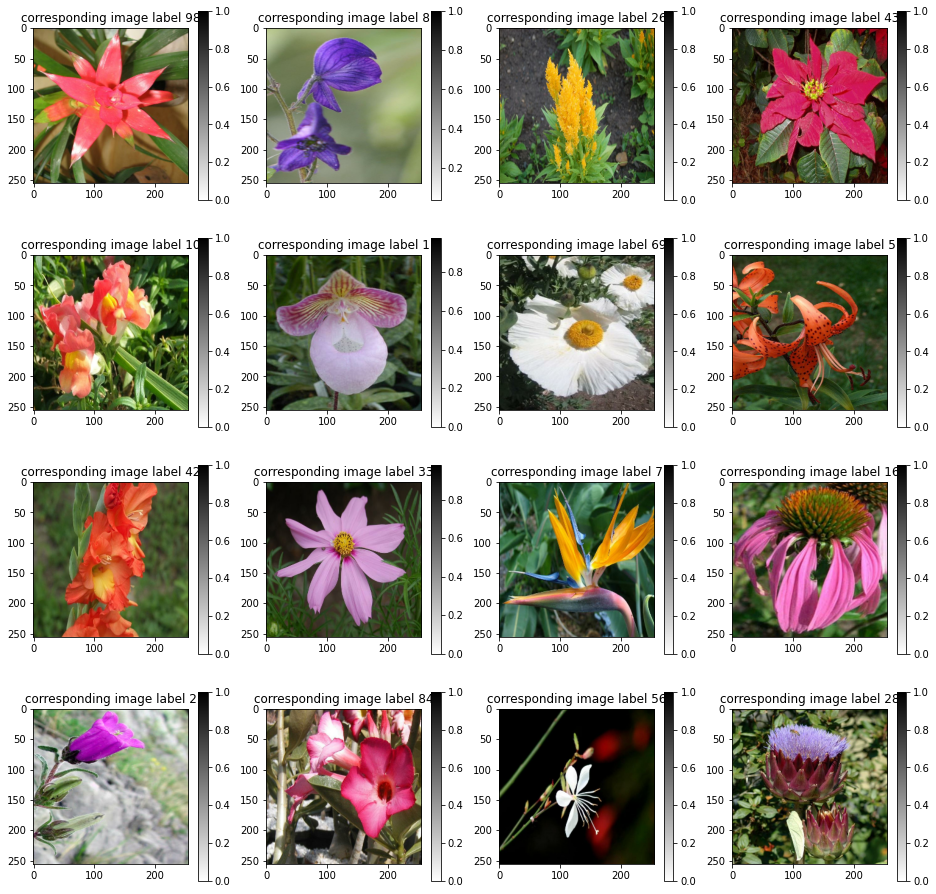

In [ ]:
ShowImages(train_Image,train_Label,4, 4, 123)

##Initial Flowers Model - Basic CNN

In [ ]:
initial_model = models.Sequential()
initial_model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=IMG_SHAPE))
initial_model.add(layers.MaxPool2D((2, 2),strides=2))
initial_model.add(layers.Dropout(0.3))
initial_model.add(layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu))
initial_model.add(layers.MaxPool2D(pool_size=(2, 2),strides=2))
initial_model.add(layers.Dropout(0.3))
initial_model.add(layers.Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu))
initial_model.add(layers.MaxPool2D(pool_size=(2, 2),strides=2))
initial_model.add(layers.Dropout(0.3))
initial_model.add(layers.Flatten())
initial_model.add(layers.Dense(units=384, activation=tf.nn.relu,kernel_regularizer=tf.keras.regularizers.L2(0.001)))
initial_model.add(layers.Dense(dataset_info.features['label'].num_classes, activation=tf.nn.softmax))

In [ ]:
initial_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 254, 254, 128)     3584      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 127, 127, 128)     0         
_________________________________________________________________
dropout (Dropout)            (None, 127, 127, 128)     0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 125, 125, 256)     295168    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 62, 62, 256)       0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 62, 62, 256)       0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 60, 60, 512)       1

In [ ]:
opt = keras.optimizers.Adam(learning_rate=0.00001)
initial_model.compile(optimizer=opt,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

NameError: ignored

In [ ]:
initial_model = initial_model.fit(test_Image
                    ,test_Label
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(val_Image, val_Label)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10),
                    tf.keras.callbacks.ModelCheckpoint('./models/model_{val_accuracy:.4f}.h5', save_best_only=True,
                                        save_weights_only=False, monitor='val_accuracy')]
                   )

Epoch 1/200
97/97 [==============================] - 45s 251ms/step - loss: 7.4855 - accuracy: 0.0558 - val_loss: 5.3019 - val_accuracy: 0.0333
Epoch 2/200
97/97 [==============================] - 22s 225ms/step - loss: 4.4395 - accuracy: 0.1125 - val_loss: 4.5089 - val_accuracy: 0.0882
Epoch 3/200
97/97 [==============================] - 22s 224ms/step - loss: 3.7664 - accuracy: 0.1737 - val_loss: 3.9512 - val_accuracy: 0.1245
Epoch 4/200
97/97 [==============================] - 22s 224ms/step - loss: 3.2953 - accuracy: 0.2583 - val_loss: 4.1127 - val_accuracy: 0.1333
Epoch 5/200
97/97 [==============================] - 22s 225ms/step - loss: 2.9987 - accuracy: 0.3176 - val_loss: 3.6018 - val_accuracy: 0.1922
Epoch 6/200
97/97 [==============================] - 22s 225ms/step - loss: 2.6703 - accuracy: 0.3903 - val_loss: 3.4833 - val_accuracy: 0.2167
Epoch 7/200
97/97 [==============================] - 22s 224ms/step - loss: 2.4277 - accuracy: 0.4479 - val_loss: 3.5095 - val_accuracy:

##Transfer Learning with Inception Model utilized for Oxford Flowers 102 Dataset

###Inception model with locked filters to classify using basic InceptionV3 with Imagenet weights

In [ ]:
Inception_model = keras.applications.InceptionV3(input_shape=IMG_SHAPE,weights='imagenet',include_top=False)


87916544/87910968 [==============================] - 1s 0us/step


In [ ]:
Inception_model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
conv2d_3 (Conv2D)               (None, 127, 127, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 127, 127, 32) 96          conv2d_3[0][0]                   
__________________________________________________________________________________________________
activation (Activation)         (None, 127, 127, 32) 0           batch_normalization[0][0]        
_______________________________________________________________________________________

In [ ]:
Inception_model.trainable = False

Incept_Flower_Trans = models.Sequential()
Incept_Flower_Trans.add(Inception_model)
Incept_Flower_Trans.add(layers.Flatten())
Incept_Flower_Trans.add(layers.Dense(dataset_info.features['label'].num_classes, activation=tf.nn.softmax))


In [ ]:
Incept_Flower_Trans.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inception_v3 (Functional)    (None, 6, 6, 2048)        21802784  
_________________________________________________________________
flatten_1 (Flatten)          (None, 73728)             0         
_________________________________________________________________
dense_2 (Dense)              (None, 102)               7520358   
Total params: 29,323,142
Trainable params: 7,520,358
Non-trainable params: 21,802,784
_________________________________________________________________


In [ ]:
Incept_Flower_Trans.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
history_Incept_Flower = Incept_Flower_Trans.fit(test_Image
                    ,test_Label
                    ,epochs=200
                    ,batch_size=64
                    ,validation_data=(val_Image, val_Label)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15),
                    tf.keras.callbacks.ModelCheckpoint('./models/locked_incept/model_{val_accuracy:.4f}.h5', save_best_only=True,
                                        save_weights_only=False, monitor='val_accuracy')]
                   )

Epoch 1/200
97/97 [==============================] - 15s 112ms/step - loss: 10.9869 - accuracy: 0.5032 - val_loss: 5.3920 - val_accuracy: 0.6490
Epoch 2/200
97/97 [==============================] - 9s 96ms/step - loss: 0.9418 - accuracy: 0.9003 - val_loss: 4.6007 - val_accuracy: 0.6990
Epoch 3/200
97/97 [==============================] - 9s 92ms/step - loss: 0.3128 - accuracy: 0.9564 - val_loss: 5.0277 - val_accuracy: 0.6647
Epoch 4/200
97/97 [==============================] - 9s 93ms/step - loss: 0.3353 - accuracy: 0.9572 - val_loss: 5.6154 - val_accuracy: 0.6814
Epoch 5/200
97/97 [==============================] - 9s 94ms/step - loss: 0.3900 - accuracy: 0.9551 - val_loss: 5.0689 - val_accuracy: 0.6980
Epoch 6/200
97/97 [==============================] - 9s 93ms/step - loss: 0.4136 - accuracy: 0.9551 - val_loss: 6.5904 - val_accuracy: 0.6931
Epoch 7/200
97/97 [==============================] - 9s 94ms/step - loss: 0.2877 - accuracy: 0.9694 - val_loss: 6.1840 - val_accuracy: 0.6657
Epo

###Unlocking Inception training to continue imrpoving model

In [ ]:
Inception_model.trainable = True


In [ ]:
history_Incept_Unlocked_Flower = Incept_Flower_Trans.fit(test_Image
                    ,test_Label
                    ,epochs=200
                    ,batch_size=32
                    ,validation_data=(val_Image, val_Label)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15),
                    tf.keras.callbacks.ModelCheckpoint('/content/gdrive/MyDrive/Backups/Incept_Unlocked/model_{val_accuracy:.4f}.h5', save_best_only=True,
                                        save_weights_only=False, monitor='val_accuracy')]
                   )

Epoch 1/200
193/193 [==============================] - 11s 55ms/step - loss: 2.5194 - accuracy: 0.9221 - val_loss: 23.2655 - val_accuracy: 0.6186
Epoch 2/200
193/193 [==============================] - 10s 53ms/step - loss: 2.1740 - accuracy: 0.9299 - val_loss: 21.1506 - val_accuracy: 0.6765
Epoch 3/200
193/193 [==============================] - 10s 53ms/step - loss: 0.8844 - accuracy: 0.9689 - val_loss: 15.9486 - val_accuracy: 0.7196
Epoch 4/200
193/193 [==============================] - 10s 53ms/step - loss: 0.3252 - accuracy: 0.9837 - val_loss: 15.4504 - val_accuracy: 0.7206
Epoch 5/200
193/193 [==============================] - 10s 52ms/step - loss: 0.5405 - accuracy: 0.9828 - val_loss: 16.9358 - val_accuracy: 0.7304
Epoch 6/200
193/193 [==============================] - 10s 53ms/step - loss: 0.4350 - accuracy: 0.9824 - val_loss: 16.4923 - val_accuracy: 0.7608
Epoch 7/200
193/193 [==============================] - 10s 54ms/step - loss: 0.3111 - accuracy: 0.9878 - val_loss: 15.7188 -

#Nitrogen Potassium and Phosphorus Deficiencies Classification Model

##Data Pull/Restructure

In [ ]:
!rm -rf '/content/data/NPK/'

In [ ]:
import zipfile
with zipfile.ZipFile("/content/gdrive/MyDrive/ML Support/HNPK.zip","r") as zip_ref:
    zip_ref.extractall("/content/data")

In [ ]:
trainDefData = tf.keras.preprocessing.image_dataset_from_directory('/content/data/HNPK/', validation_split = .15, seed = 21, subset = 'training')
valDefData = tf.keras.preprocessing.image_dataset_from_directory('/content/data/HNPK/', validation_split = .15, seed = 21, subset = 'validation')

Found 728 files belonging to 4 classes.
Using 619 files for training.
Found 728 files belonging to 4 classes.
Using 109 files for validation.


In [ ]:
print(trainDefData.class_names)
print(valDefData.class_names)

['Healthy', 'Nitrogen', 'Phosphorus', 'Potassium']
['Healthy', 'Nitrogen', 'Phosphorus', 'Potassium']


In [ ]:
trainDef = trainDefData.map(resize_normalize)
valDef = valDefData.map(resize_normalize)

In [ ]:
def unpackData(input_data):
  numpy_images = np.empty((0,IMG_SIZE,IMG_SIZE,3),'float32')#np.empty((0,3),'float32')
  numpy_labels = np.empty((0,),int)
  firstRun = True
  for images, labels in input_data:
    for x in images:
      numpy_images = np.append(numpy_images,np.expand_dims(x,axis = 0),axis = 0)
    for y in labels:
      numpy_labels = np.append(numpy_labels,np.expand_dims(y,axis = 0),axis = 0)

  return numpy_images, numpy_labels

In [ ]:
x,y = unpackData(trainDef)
def_train_imgs, def_train_labels = splitDatasetXY(x,y)
x,y = unpackData(valDef)
def_val_imgs, def_val_labels = splitDatasetXY(x,y )

##EDA

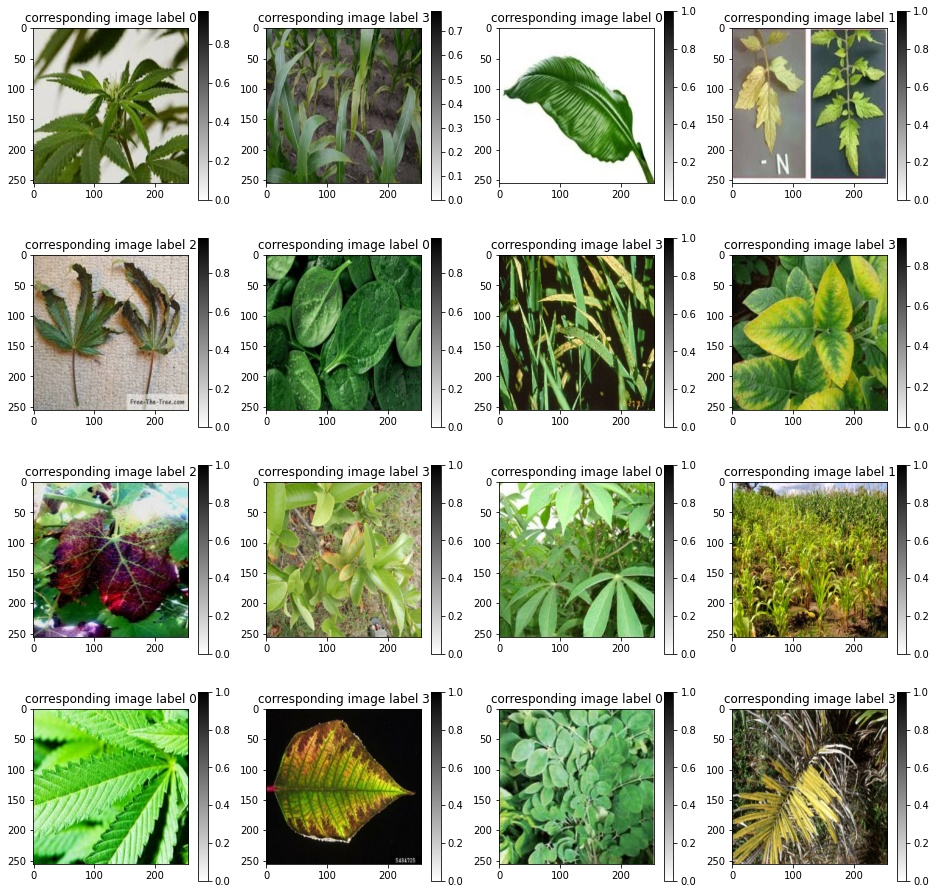

In [ ]:
#Show Images with Labels to verify
ShowImages(def_train_imgs,def_train_labels,4, 4, 123)

##Transfer learn from best performing Flowers model to NPK dataset

Load best performing Flowers model as baseline for project in order to utilize pre-trained filters

In [ ]:
def_model = tf.keras.models.load_model('/content/gdrive/MyDrive/Backups/model_0.7814.h5')

In [ ]:
def_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inception_v3 (Functional)    (None, 6, 6, 2048)        21802784  
_________________________________________________________________
flatten_1 (Flatten)          (None, 73728)             0         
_________________________________________________________________
dense_2 (Dense)              (None, 102)               7520358   
Total params: 29,323,142
Trainable params: 7,520,358
Non-trainable params: 21,802,784
_________________________________________________________________


Remove final classification layer

In [ ]:
def_model.pop()

In [ ]:
def_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inception_v3 (Functional)    (None, 6, 6, 2048)        21802784  
_________________________________________________________________
flatten_1 (Flatten)          (None, 73728)             0         
Total params: 21,802,784
Trainable params: 0
Non-trainable params: 21,802,784
_________________________________________________________________


Add back classification layer for NPK + Healthy

In [ ]:
def_model.add(layers.Dense(4, activation=tf.nn.softmax))

In [ ]:
def_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inception_v3 (Functional)    (None, 6, 6, 2048)        21802784  
_________________________________________________________________
flatten_1 (Flatten)          (None, 73728)             0         
_________________________________________________________________
dense (Dense)                (None, 3)                 221187    
Total params: 22,023,971
Trainable params: 221,187
Non-trainable params: 21,802,784
_________________________________________________________________


Setup optimizer with adjusted learning rate and train model

In [ ]:
adamOpt = tf.keras.optimizers.Adam(learning_rate=0.000005)


def_model.compile(optimizer=adamOpt,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
history_Def = def_model.fit(def_train_imgs
                    ,def_train_labels
                    ,epochs=200
                    ,batch_size=16
                    ,validation_data=(def_val_imgs, def_val_labels)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=200),
                    tf.keras.callbacks.ModelCheckpoint('/content/gdrive/MyDrive/Backups/NPK/model_TransIncept_{val_accuracy:.4f}.h5', save_best_only=True,
                                        save_weights_only=False, monitor='val_accuracy')]
                   )

Epoch 1/200
38/38 [==============================] - 9s 127ms/step - loss: 1.5922 - accuracy: 0.2977 - val_loss: 1.4568 - val_accuracy: 0.3667
Epoch 2/200
38/38 [==============================] - 3s 82ms/step - loss: 1.4382 - accuracy: 0.3470 - val_loss: 1.4174 - val_accuracy: 0.3833
Epoch 3/200
38/38 [==============================] - 3s 91ms/step - loss: 1.3268 - accuracy: 0.3914 - val_loss: 1.3776 - val_accuracy: 0.4167
Epoch 4/200
38/38 [==============================] - 3s 91ms/step - loss: 1.2264 - accuracy: 0.4539 - val_loss: 1.3506 - val_accuracy: 0.4250
Epoch 5/200
38/38 [==============================] - 3s 85ms/step - loss: 1.1422 - accuracy: 0.4951 - val_loss: 1.3308 - val_accuracy: 0.4500
Epoch 6/200
38/38 [==============================] - 2s 64ms/step - loss: 1.0695 - accuracy: 0.5461 - val_loss: 1.3140 - val_accuracy: 0.4500
Epoch 7/200
38/38 [==============================] - 2s 64ms/step - loss: 0.9982 - accuracy: 0.5872 - val_loss: 1.2995 - val_accuracy: 0.4250
Epoch

In [ ]:
losses = history_Def.history['loss']
accs = history_Def.history['accuracy']
val_losses = history_Def.history['val_loss']
val_accs = history_Def.history['val_accuracy']
epochs = len(losses)



---

Plotting Acuracy across batches


---



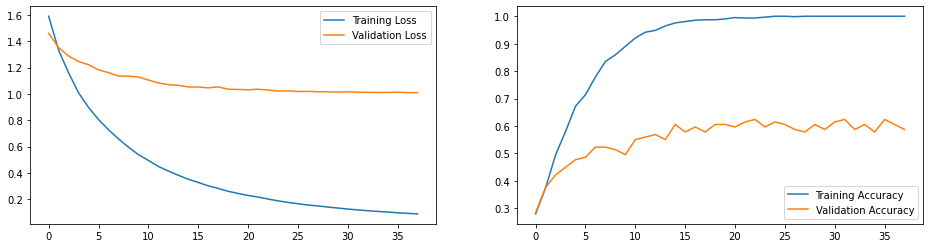

In [ ]:
plt.figure(figsize=(16, 4))
for i, metrics in enumerate(zip([losses, accs], [val_losses, val_accs], ['Loss', 'Accuracy'])):
    plt.subplot(1, 2, i + 1)
    plt.plot(range(epochs), metrics[0], label='Training {}'.format(metrics[2]))
    plt.plot(range(epochs), metrics[1], label='Validation {}'.format(metrics[2]))
    plt.legend()
plt.show()

In [ ]:
predicts = def_model.predict_classes(def_val_imgs)
predicts_all = def_model.predict(def_val_imgs)

Plot Confusion Matrix for validation data

In [ ]:
confus = tf.math.confusion_matrix(def_val_labels,predicts)
print(confus)

tf.Tensor(
[[ 8  4  2  2]
 [ 3 22  6  5]
 [ 0  3 20  3]
 [ 2  6  5 18]], shape=(4, 4), dtype=int32)


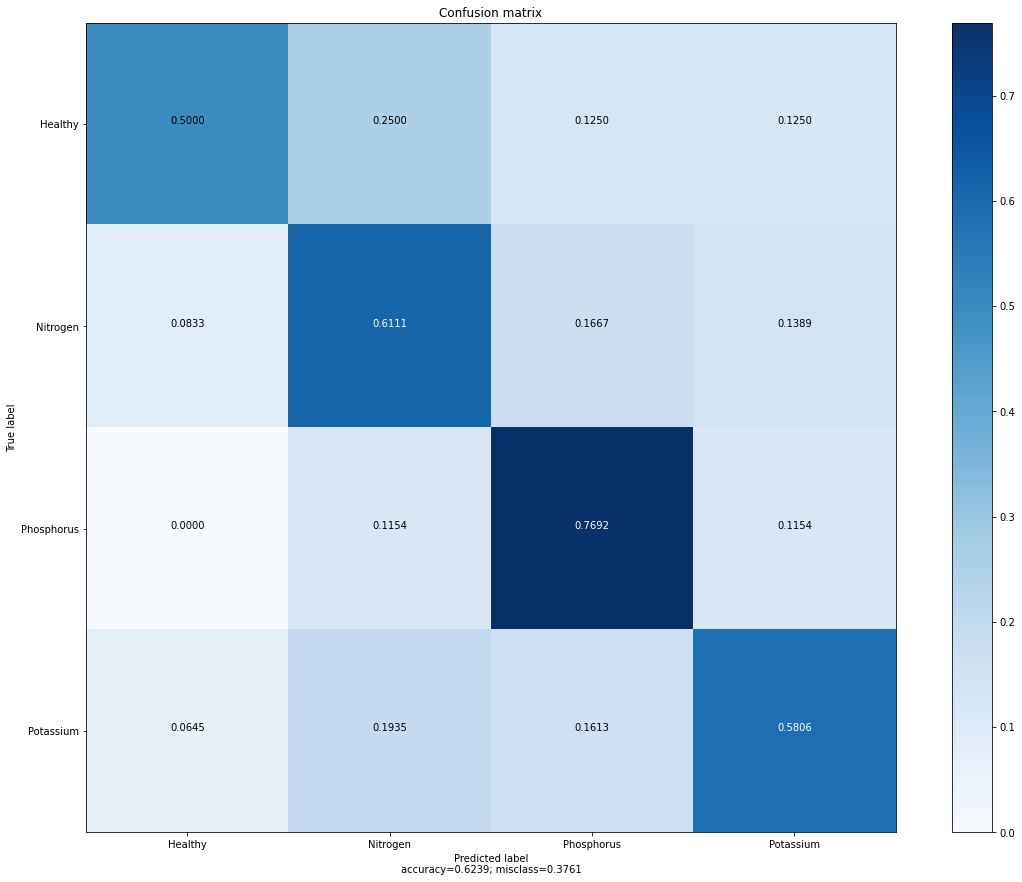

In [ ]:
plot_confusion_matrix(confus.numpy(),target_names=valDefData.class_names)



---


Explore Classified Validation Images

---



In [ ]:
picked_images, picked_labels, picked_preds = pickImages(def_val_imgs,def_val_labels,predicts_all, 4, 123, valDefData.class_names)

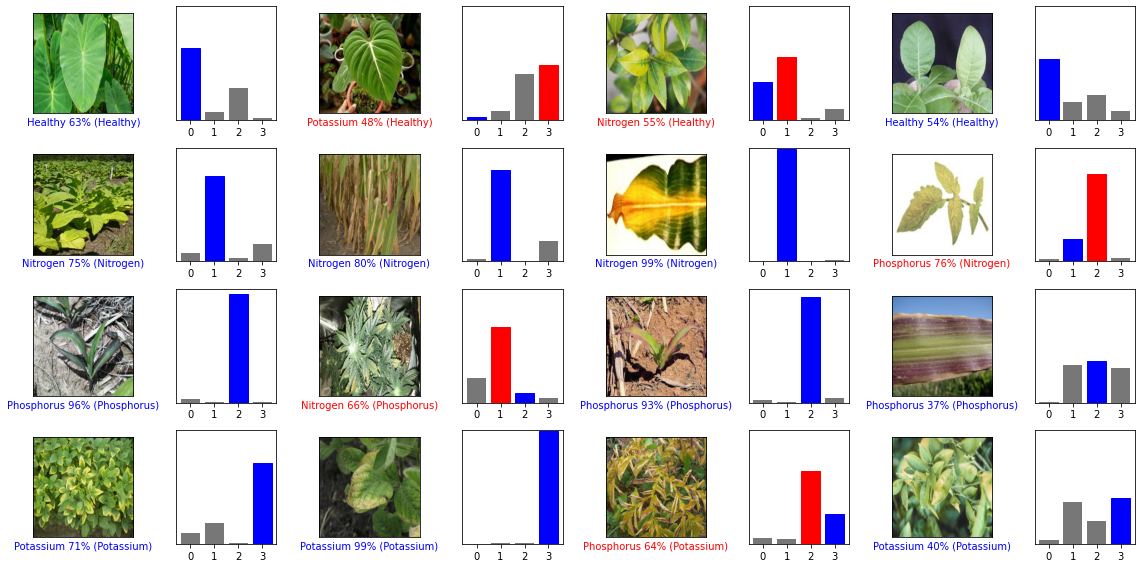

In [ ]:
plot_Images_Preds(4, 4, picked_images,picked_preds,picked_labels, valDefData.class_names)

##Test NPK dataset with baseline InceptionV3 model again utilizing imagenet weights

In [ ]:
Inception_model = keras.applications.InceptionV3(input_shape=IMG_SHAPE,weights='imagenet',include_top=False)

In [ ]:
Inception_model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
conv2d_188 (Conv2D)             (None, 127, 127, 32) 864         input_3[0][0]                    
__________________________________________________________________________________________________
batch_normalization_188 (BatchN (None, 127, 127, 32) 96          conv2d_188[0][0]                 
__________________________________________________________________________________________________
activation_188 (Activation)     (None, 127, 127, 32) 0           batch_normalization_188[0][0]    
_______________________________________________________________________________________

In [ ]:
def_Inception = models.Sequential()
def_Inception.add(Inception_model)
def_Inception.add(layers.Flatten())
def_Inception.add(layers.Dense(4, activation=tf.nn.softmax))

In [ ]:
adamOpt = tf.keras.optimizers.Adam(learning_rate=0.00001)


def_Inception.compile(optimizer=adamOpt,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
history_Def_Incep = def_Inception.fit(def_train_imgs
                    ,def_train_labels
                    ,epochs=200
                    ,batch_size=16
                    ,validation_data=(def_val_imgs, def_val_labels)
                    ,callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15),
                    tf.keras.callbacks.ModelCheckpoint('/content/gdrive/MyDrive/Backups/NPK_Ince/model_{val_accuracy:.4f}.h5', save_best_only=True,
                                        save_weights_only=False, monitor='val_accuracy')]
                   )

Epoch 1/200
39/39 [==============================] - 12s 143ms/step - loss: 1.5544 - accuracy: 0.3053 - val_loss: 1.5444 - val_accuracy: 0.3119
Epoch 2/200
39/39 [==============================] - 5s 116ms/step - loss: 1.0944 - accuracy: 0.5412 - val_loss: 1.4926 - val_accuracy: 0.2936
Epoch 3/200
39/39 [==============================] - 5s 116ms/step - loss: 0.8231 - accuracy: 0.7060 - val_loss: 1.4415 - val_accuracy: 0.3211
Epoch 4/200
39/39 [==============================] - 5s 119ms/step - loss: 0.6459 - accuracy: 0.8061 - val_loss: 1.3913 - val_accuracy: 0.3394
Epoch 5/200
39/39 [==============================] - 5s 120ms/step - loss: 0.4957 - accuracy: 0.8966 - val_loss: 1.3651 - val_accuracy: 0.4128
Epoch 6/200
39/39 [==============================] - 5s 118ms/step - loss: 0.3922 - accuracy: 0.9241 - val_loss: 1.3466 - val_accuracy: 0.4220
Epoch 7/200
39/39 [==============================] - 5s 117ms/step - loss: 0.2923 - accuracy: 0.9677 - val_loss: 1.3485 - val_accuracy: 0.422

In [ ]:
losses_Incep = history_Def_Incep.history['loss']
accs_Incep = history_Def_Incep.history['accuracy']
val_losses_Incep = history_Def_Incep.history['val_loss']
val_accs_Incep = history_Def_Incep.history['val_accuracy']
epochs_Incep = len(losses_Incep)

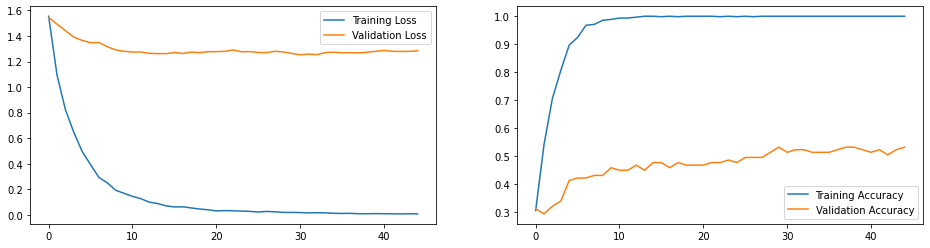

In [ ]:
plt.figure(figsize=(16, 4))
for i, metrics in enumerate(zip([losses_Incep, accs_Incep], [val_losses_Incep, val_accs_Incep], ['Loss', 'Accuracy'])):
    plt.subplot(1, 2, i + 1)
    plt.plot(range(epochs_Incep), metrics[0], label='Training {}'.format(metrics[2]))
    plt.plot(range(epochs_Incep), metrics[1], label='Validation {}'.format(metrics[2]))
    plt.legend()
plt.show()

#Capsule Network Comparison

In [ ]:
!rm -rf '/content/data/NPK/'
import zipfile
with zipfile.ZipFile("/content/gdrive/MyDrive/ML Support/HNPK.zip","r") as zip_ref:
    zip_ref.extractall("/content/data")

In [ ]:
trainDefData = tf.keras.preprocessing.image_dataset_from_directory('/content/data/HNPK/', validation_split = .1649, seed = 21, subset = 'training')
valDefData = tf.keras.preprocessing.image_dataset_from_directory('/content/data/HNPK/', validation_split = .1649, seed = 21, subset = 'validation')

Found 728 files belonging to 4 classes.
Using 608 files for training.
Found 728 files belonging to 4 classes.
Using 120 files for validation.


In [ ]:
trainDef = trainDefData.map(resize_normalize)
valDef = valDefData.map(resize_normalize)

In [ ]:
def unpackData(input_data):
  numpy_images = np.empty((0,IMG_SIZE,IMG_SIZE,3),'float32')#np.empty((0,3),'float32')
  numpy_labels = np.empty((0,),int)
  firstRun = True
  for images, labels in input_data:
    for x in images:
      numpy_images = np.append(numpy_images,np.expand_dims(x,axis = 0),axis = 0)
    for y in labels:
      numpy_labels = np.append(numpy_labels,np.expand_dims(y,axis = 0),axis = 0)

  return numpy_images, numpy_labels

In [ ]:
x,y = unpackData(trainDef)
def_train_imgs, def_train_labels = splitDatasetXY(x,y)
x,y = unpackData(valDef)
def_val_imgs, def_val_labels = splitDatasetXY(x,y )

##Capsule Network

In [ ]:
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from datetime import datetime


%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
%reload_ext tensorboard

In [ ]:
# Parameters Based on Paper
epsilon = 1e-7
m_plus = 0.9
m_minus = 0.1
lambda_ = 0.5
alpha = 0.0005
epochs = 50
no_of_secondary_capsules = 4

optimizer = tf.keras.optimizers.Adam()

In [ ]:
params = {
    "no_of_conv_kernels": 256,
    "no_of_primary_capsules": 49,
    "no_of_secondary_capsules": 4,
    "primary_capsule_vector": 8,
    "secondary_capsule_vector": 16,
    "r":3,
}

In [ ]:
checkpoint_path = './logs/model/capsule'

stamp = datetime.now().strftime("%Y%m%d-%H%M%S")

logdir = './logs/func/%s' % stamp
writer = tf.summary.create_file_writer(logdir)

scalar_logdir = './logs/scalars/%s' % stamp
file_writer = tf.summary.create_file_writer(scalar_logdir + "/metrics")

In [ ]:
X_train = def_train_imgs
y_train = def_train_labels

X_test = def_val_imgs
y_test = def_val_labels

In [ ]:
testing_dataset_size = X_test.shape[0]
training_dataset_size = X_train.shape[0]

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)

(608, 256, 256, 3)
(608,)
(120, 256, 256, 3)


In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.shuffle(buffer_size=len(dataset), reshuffle_each_iteration=True)
dataset = dataset.batch(batch_size=64)
#dataset = trainDef
#dataset = dataset.batch(batch_size=64)

In [ ]:
testing = tf.data.Dataset.from_tensor_slices((X_test, y_test))
testing = testing.batch(batch_size=64)

In [ ]:
class CapsuleNetwork(tf.keras.Model):
    def __init__(self, no_of_conv_kernels, no_of_primary_capsules, primary_capsule_vector, no_of_secondary_capsules, secondary_capsule_vector, r):
        super(CapsuleNetwork, self).__init__()
        self.no_of_conv_kernels = no_of_conv_kernels
        self.no_of_primary_capsules = no_of_primary_capsules
        self.primary_capsule_vector = primary_capsule_vector
        self.no_of_secondary_capsules = no_of_secondary_capsules
        self.secondary_capsule_vector = secondary_capsule_vector
        self.r = r


        with tf.name_scope("Variables") as scope:
            self.convolution = tf.keras.layers.Conv2D(self.no_of_conv_kernels, [22,22], strides=[6,6], name='ConvolutionLayer', activation='relu')
            self.primary_capsule = tf.keras.layers.Conv2D(self.no_of_primary_capsules * self.primary_capsule_vector, [22,22], strides=[3,3], name="PrimaryCapsule")
            self.w = tf.Variable(tf.random_normal_initializer()(shape=[1, 2401, self.no_of_secondary_capsules, self.secondary_capsule_vector, self.primary_capsule_vector]), dtype=tf.float32, name="PoseEstimation", trainable=True)
            self.dense_1 = tf.keras.layers.Dense(units = 512, activation='relu')
            self.dense_2 = tf.keras.layers.Dense(units = 1024, activation='relu')
            self.dense_3 = tf.keras.layers.Dense(units = 196608, activation='sigmoid', dtype='float32')

    def build(self, input_shape):
        pass

    def squash(self, s):
        with tf.name_scope("SquashFunction") as scope:
            s_norm = tf.norm(s, axis=-1, keepdims=True)
            return tf.square(s_norm)/(1 + tf.square(s_norm)) * s/(s_norm + epsilon)

    @tf.function
    def call(self, inputs):
        input_x, y = inputs
        # input_x.shape: (None, 28, 28, 1)
        # y.shape: (None, 10)

        x = self.convolution(input_x) # x.shape: (None, 20, 20, 256)
        x = self.primary_capsule(x) # x.shape: (None, 6, 6, 256)

        with tf.name_scope("CapsuleFormation") as scope:
            u = tf.reshape(x, (-1, self.no_of_primary_capsules * x.shape[1] * x.shape[2], 8)) # u.shape: (None, 1152, 8)
            u = tf.expand_dims(u, axis=-2) # u.shape: (None, 1152, 1, 8)
            u = tf.expand_dims(u, axis=-1) # u.shape: (None, 1152, 1, 8, 1)
            u_hat = tf.matmul(self.w, u) # u_hat.shape: (None, 1152, 10, 16, 1)
            u_hat = tf.squeeze(u_hat, [4]) # u_hat.shape: (None, 1152, 10, 16)


        with tf.name_scope("DynamicRouting") as scope:
            b = tf.zeros((input_x.shape[0], 2401, self.no_of_secondary_capsules, 1)) # b.shape: (None, 1152, 10, 1)
            for i in range(self.r): # self.r = 3
                c = tf.nn.softmax(b, axis=-2) # c.shape: (None, 1152, 10, 1)
                s = tf.reduce_sum(tf.multiply(c, u_hat), axis=1, keepdims=True) # s.shape: (None, 1, 10, 16)
                v = self.squash(s) # v.shape: (None, 1, 10, 16)
                agreement = tf.squeeze(tf.matmul(tf.expand_dims(u_hat, axis=-1), tf.expand_dims(v, axis=-1), transpose_a=True), [4]) # agreement.shape: (None, 1152, 10, 1)
                # Before matmul following intermediate shapes are present, they are not assigned to a variable but just for understanding the code.
                # u_hat.shape (Intermediate shape) : (None, 1152, 10, 16, 1)
                # v.shape (Intermediate shape): (None, 1, 10, 16, 1)
                # Since the first parameter of matmul is to be transposed its shape becomes:(None, 1152, 10, 1, 16)
                # Now matmul is performed in the last two dimensions, and others are broadcasted
                # Before squeezing we have an intermediate shape of (None, 1152, 10, 1, 1)
                b += agreement

        with tf.name_scope("Masking") as scope:
            y = tf.expand_dims(y, axis=-1) # y.shape: (None, 10, 1)
            y = tf.expand_dims(y, axis=1) # y.shape: (None, 1, 10, 1)
            mask = tf.cast(y, dtype=tf.float32) # mask.shape: (None, 1, 10, 1)
            v_masked = tf.multiply(mask, v) # v_masked.shape: (None, 1, 10, 16)

        with tf.name_scope("Reconstruction") as scope:
            v_ = tf.reshape(v_masked, [-1, self.no_of_secondary_capsules * self.secondary_capsule_vector]) # v_.shape: (None, 160)
            reconstructed_image = self.dense_1(v_) # reconstructed_image.shape: (None, 512)
            reconstructed_image = self.dense_2(reconstructed_image) # reconstructed_image.shape: (None, 1024)
            reconstructed_image = self.dense_3(reconstructed_image) # reconstructed_image.shape: (None, 784)

        return v, reconstructed_image

    @tf.function
    def predict_capsule_output(self, inputs):
        x = self.convolution(inputs) # x.shape: (None, 20, 20, 256)
        x = self.primary_capsule(x) # x.shape: (None, 6, 6, 256)

        with tf.name_scope("CapsuleFormation") as scope:
            u = tf.reshape(x, (-1, self.no_of_primary_capsules * x.shape[1] * x.shape[2], 8)) # u.shape: (None, 1152, 8)
            u = tf.expand_dims(u, axis=-2) # u.shape: (None, 1152, 1, 8)
            u = tf.expand_dims(u, axis=-1) # u.shape: (None, 1152, 1, 8, 1)
            u_hat = tf.matmul(self.w, u) # u_hat.shape: (None, 1152, 10, 16, 1)
            u_hat = tf.squeeze(u_hat, [4]) # u_hat.shape: (None, 1152, 10, 16)


        with tf.name_scope("DynamicRouting") as scope:
            b = tf.zeros((inputs.shape[0], 2401, self.no_of_secondary_capsules, 1)) # b.shape: (None, 1152, 10, 1)
            for i in range(self.r): # self.r = 3
                c = tf.nn.softmax(b, axis=-2) # c.shape: (None, 1152, 10, 1)
                s = tf.reduce_sum(tf.multiply(c, u_hat), axis=1, keepdims=True) # s.shape: (None, 1, 10, 16)
                v = self.squash(s) # v.shape: (None, 1, 10, 16)
                agreement = tf.squeeze(tf.matmul(tf.expand_dims(u_hat, axis=-1), tf.expand_dims(v, axis=-1), transpose_a=True), [4]) # agreement.shape: (None, 1152, 10, 1)
                # Before matmul following intermediate shapes are present, they are not assigned to a variable but just for understanding the code.
                # u_hat.shape (Intermediate shape) : (None, 1152, 10, 16, 1)
                # v.shape (Intermediate shape): (None, 1, 10, 16, 1)
                # Since the first parameter of matmul is to be transposed its shape becomes:(None, 1152, 10, 1, 16)
                # Now matmul is performed in the last two dimensions, and others are broadcasted
                # Before squeezing we have an intermediate shape of (None, 1152, 10, 1, 1)
                b += agreement
        return v

    @tf.function
    def regenerate_image(self, inputs):
        with tf.name_scope("Reconstruction") as scope:
            v_ = tf.reshape(inputs, [-1, self.no_of_secondary_capsules * self.secondary_capsule_vector]) # v_.shape: (None, 160)
            reconstructed_image = self.dense_1(v_) # reconstructed_image.shape: (None, 512)
            reconstructed_image = self.dense_2(reconstructed_image) # reconstructed_image.shape: (None, 1024)
            reconstructed_image = self.dense_3(reconstructed_image) # reconstructed_image.shape: (None, 784)
        return reconstructed_image

In [ ]:
tf.summary.trace_on(graph=True, profiler=True)

In [ ]:
model = CapsuleNetwork(**params)

In [ ]:
def safe_norm(v, axis=-1, epsilon=1e-7):
    v_ = tf.reduce_sum(tf.square(v), axis = axis, keepdims=True)
    return tf.sqrt(v_ + epsilon)

In [ ]:
def loss_function(v, reconstructed_image, y, y_image):
    prediction = safe_norm(v)
    prediction = tf.reshape(prediction, [-1, no_of_secondary_capsules])

    left_margin = tf.square(tf.maximum(0.0, m_plus - prediction))
    right_margin = tf.square(tf.maximum(0.0, prediction - m_minus))

    l = tf.add(y * left_margin, lambda_ * (1.0 - y) * right_margin)

    margin_loss = tf.reduce_mean(tf.reduce_sum(l, axis=-1))

    y_image_flat = tf.reshape(y_image, [-1, 196608])
    reconstruction_loss = tf.reduce_mean(tf.square(y_image_flat - reconstructed_image))

    loss = tf.add(margin_loss, alpha * reconstruction_loss)

    return loss

In [ ]:
def train(x,y):
    y_one_hot = tf.one_hot(y, depth=4)
    with tf.GradientTape() as tape:
        v, reconstructed_image = model([x, y_one_hot])
        loss = loss_function(v, reconstructed_image, y_one_hot, x)
    grad = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grad, model.trainable_variables))
    return loss

In [ ]:
_ = train(X_train[:32],y_train[:32])
with writer.as_default():
    tf.summary.trace_export(name="my_func_trace", step=0, profiler_outdir=logdir)

In [ ]:
tf.summary.trace_off()

In [ ]:
model.summary()

Model: "capsule_network_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ConvolutionLayer (Conv2D)   multiple                  371968    
                                                                 
 PrimaryCapsule (Conv2D)     multiple                  48570760  
                                                                 
 dense_6 (Dense)             multiple                  33280     
                                                                 
 dense_7 (Dense)             multiple                  525312    
                                                                 
 dense_8 (Dense)             multiple                  201523200 
                                                                 
Total params: 252,253,832
Trainable params: 252,253,832
Non-trainable params: 0
_________________________________________________________________


In [ ]:
def predict(model, x):
    pred = safe_norm(model.predict_capsule_output(x))
    pred = tf.squeeze(pred, [1])
    return np.argmax(pred, axis=1)[:,0]

In [ ]:
checkpoint = tf.train.Checkpoint(model=model)

In [ ]:
losses = []
accuracy = []
for i in range(1, epochs+1, 1):

    loss = 0
    with tqdm(total=len(dataset)) as pbar:

        description = "Epoch " + str(i) + "/" + str(epochs)
        pbar.set_description_str(description)

        for X_batch, y_batch in dataset:

            loss += train(X_batch,y_batch)
            pbar.update(1)

        loss /= len(dataset)
        losses.append(loss.numpy())

        training_sum = 0

        print_statement = "Loss :" + str(loss.numpy()) + " Evaluating Accuracy ..."
        pbar.set_postfix_str(print_statement)

        for X_batch, y_batch in dataset:
            training_sum += sum(predict(model, X_batch)==y_batch.numpy())
        accuracy.append(training_sum/training_dataset_size)

        with file_writer.as_default():
            tf.summary.scalar('Loss', data=loss.numpy(), step=i)
            tf.summary.scalar('Accuracy', data=accuracy[-1], step=i)

        print_statement = "Loss :" + str(loss.numpy()) + " Accuracy :" + str(accuracy[-1])

        if i % 10 == 0:
            print_statement += ' Checkpoint Saved'
            checkpoint.save(checkpoint_path)

        pbar.set_postfix_str(print_statement)

Epoch 50/50: 100%|██████████| 10/10 [00:11<00:00,  1.12s/it, Loss :1.215037 Accuracy :0.1875 Checkpoint Saved]


In [ ]:
model.save_weights('/content/gdrive/MyDrive/Backups/capsules/')

In [ ]:
model.load_weights('/content/gdrive/MyDrive/Backups/capsules/')

In [ ]:
test_sum = 0
for X_batch, y_batch in testing:
    test_sum += sum(predict(model, X_batch)==y_batch.numpy())
print(test_sum/testing_dataset_size)

0.19166666666666668


In [ ]:
Y_Pred = predict(model, X_test)
Y_test = def_val_labels.flatten()

In [ ]:
print(Y_Pred.flatten().shape)
print(Y_test.shape)
print(X_batch.shape)

(120,)
(120,)
(56, 256, 256, 3)


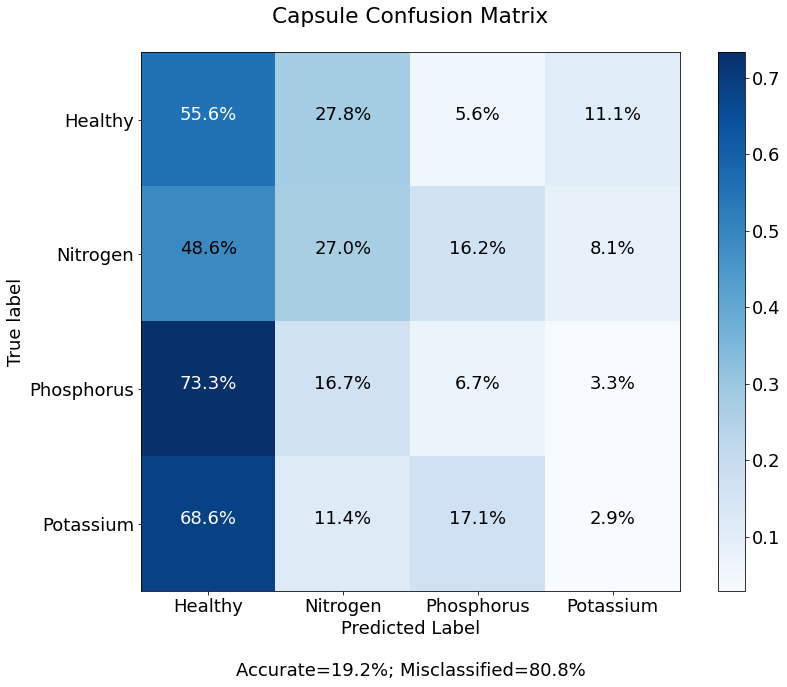

In [ ]:
plot_confusion_matrix(confusion_matrix(def_val_labels, Y_Pred),target_names=valDefData.class_names,title = 'Capsule Confusion Matrix\n')

In [ ]:
test_sum = 0
for X_batch, y_batch in testing:
    print(f'Prediction: {predict(model, X_batch)} Actual: {y_batch.numpy()}')
print(test_sum/testing_dataset_size)

Prediction: [0 1 0 1 0 0 0 0 0 0 2 0 0 0 0 0 3 0 0 0 1 2 0 1 0 1 0 0 0 1 1 1 2 0 0 1 0
 0 0 0 0 0 1 0 0 0 0 0 2 2 2 0 0 2 0 2 0 0 3 1 1 3 2 1] Actual: [1 3 1 2 3 3 1 2 3 2 1 3 2 2 3 1 2 3 0 0 0 1 3 0 3 3 3 0 3 1 1 0 3 2 0 2 0
 3 1 2 2 1 3 2 1 3 1 1 1 3 0 1 3 1 3 2 0 2 0 3 1 1 1 2]
Prediction: [1 0 0 0 1 2 2 3 0 1 0 0 0 0 0 0 0 0 0 0 0 0 2 0 1 0 0 0 1 0 3 1 2 0 1 0 0
 0 0 0 1 0 0 2 1 3 0 1 0 0 3 0 1 0 2 0] Actual: [1 1 3 2 1 3 3 1 2 1 3 3 2 1 3 0 2 1 2 3 0 2 2 2 1 1 1 2 1 2 1 1 3 2 0 3 1
 3 1 1 2 3 3 3 2 0 0 0 0 2 3 2 1 2 1 3]
0.0


In [ ]:
model = tf.keras.load()

In [ ]:
x = model.predict_capsule_output(X_batch)


In [ ]:
x.shape
#X_batch.shape

TensorShape([56, 1, 4, 16])

#RBM

##Deficiency Load

In [ ]:
!rm -rf '/content/data/NPK/'
import zipfile
with zipfile.ZipFile("/content/gdrive/MyDrive/ML Support/HNPK.zip","r") as zip_ref:
    zip_ref.extractall("/content/data")

In [ ]:
def resize_normalize_rbm(image,label):
  image = tf.cast(image,tf.float32)
  image = tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
  image = image / 16.0
  return image,label

In [ ]:
trainDefData = tf.keras.preprocessing.image_dataset_from_directory('/content/data/HNPK/', validation_split = .1649, seed = 21, subset = 'training')
valDefData = tf.keras.preprocessing.image_dataset_from_directory('/content/data/HNPK/', validation_split = .1649, seed = 21, subset = 'validation')

Found 728 files belonging to 4 classes.
Using 608 files for training.
Found 728 files belonging to 4 classes.
Using 120 files for validation.


In [ ]:
IMG_SIZE = 128

In [ ]:
trainDef = trainDefData.map(resize_normalize_rbm)
valDef = valDefData.map(resize_normalize_rbm)

In [ ]:
def unpackData(input_data):
  numpy_images = np.empty((0,IMG_SIZE,IMG_SIZE,3),'float32')#np.empty((0,3),'float32')
  numpy_labels = np.empty((0,),int)
  firstRun = True
  for images, labels in input_data:
    for x in images:
      numpy_images = np.append(numpy_images,np.expand_dims(x,axis = 0),axis = 0)
    for y in labels:
      numpy_labels = np.append(numpy_labels,np.expand_dims(y,axis = 0),axis = 0)

  return numpy_images, numpy_labels

In [ ]:
x,y = unpackData(trainDef)
def_train_imgs, def_train_labels = splitDatasetXY(x,y)
x,y = unpackData(valDef)
def_val_imgs, def_val_labels = splitDatasetXY(x,y )

##RBM Libraries

In [ ]:
from abc import ABCMeta, abstractmethod

import numpy as np


class ActivationFunction(object):
    """
    Class for abstract activation function.
    """
    __metaclass__ = ABCMeta

    @abstractmethod
    def function(self, x):
        return

    @abstractmethod
    def prime(self, x):
        return


class SigmoidActivationFunction(ActivationFunction):
    @classmethod
    def function(cls, x):
        """
        Sigmoid function.
        :param x: array-like, shape = (n_features, )
        :return:
        """
        return 1 / (1.0 + np.exp(-x))

    @classmethod
    def prime(cls, x):
        """
        Compute sigmoid first derivative.
        :param x: array-like, shape = (n_features, )
        :return:
        """
        return x * (1 - x)


class ReLUActivationFunction(ActivationFunction):
    @classmethod
    def function(cls, x):
        """
        Rectified linear function.
        :param x: array-like, shape = (n_features, )
        :return:
        """
        return np.maximum(np.zeros(x.shape), x)

    @classmethod
    def prime(cls, x):
        """
        Rectified linear first derivative.
        :param x: array-like, shape = (n_features, )
        :return:
        """
        return (x > 0).astype(int)


class TanhActivationFunction(ActivationFunction):
    @classmethod
    def function(cls, x):
        """
        Hyperbolic tangent function.
        :param x: array-like, shape = (n_features, )
        :return:
        """
        return np.tanh(x)

    @classmethod
    def prime(cls, x):
        """
        Hyperbolic tangent first derivative.
        :param x: array-like, shape = (n_features, )
        :return:
        """
        return 1 - x * x

def batch_generator(batch_size, data, labels=None):
    """
    Generates batches of samples
    :param data: array-like, shape = (n_samples, n_features)
    :param labels: array-like, shape = (n_samples, )
    :return:
    """
    n_batches = int(np.ceil(len(data) / float(batch_size)))
    idx = np.random.permutation(len(data))
    data_shuffled = data[idx]
    if labels is not None:
        labels_shuffled = labels[idx]
    for i in range(n_batches):
        start = i * batch_size
        end = start + batch_size
        if labels is not None:
            yield data_shuffled[start:end, :], labels_shuffled[start:end]
        else:
            yield data_shuffled[start:end, :]


def to_categorical(labels, num_classes):
    """
    Converts labels as single integer to row vectors. For instance, given a three class problem, labels would be
    mapped as label_1: [1 0 0], label_2: [0 1 0], label_3: [0, 0, 1] where labels can be either int or string.
    :param labels: array-like, shape = (n_samples, )
    :return:
    """
    new_labels = np.zeros([len(labels), num_classes])
    label_to_idx_map, idx_to_label_map = dict(), dict()
    idx = 0
    for i, label in enumerate(labels):
        if label not in label_to_idx_map:
            label_to_idx_map[label] = idx
            idx_to_label_map[idx] = label
            idx += 1
        new_labels[i][label_to_idx_map[label]] = 1
    return new_labels, label_to_idx_map, idx_to_label_map

In [ ]:
from abc import ABCMeta, abstractmethod

import numpy as np
from scipy.stats import truncnorm
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, RegressorMixin

class BaseModel(object):
    def save(self, save_path):
        import pickle

        with open(save_path, 'wb') as fp:
            pickle.dump(self, fp)

    @classmethod
    def load(cls, load_path):
        import pickle

        with open(load_path, 'rb') as fp:
            return pickle.load(fp)


class BaseBinaryRBM(BaseEstimator, TransformerMixin, BaseModel):
    """
    This class implements a Binary Restricted Boltzmann machine.
    """

    def __init__(self,
                 n_hidden_units=100,
                 activation_function='sigmoid',
                 optimization_algorithm='sgd',
                 learning_rate=1e-3,
                 n_epochs=10,
                 contrastive_divergence_iter=1,
                 batch_size=32,
                 verbose=True):
        self.n_hidden_units = n_hidden_units
        self.activation_function = activation_function
        self.optimization_algorithm = optimization_algorithm
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.contrastive_divergence_iter = contrastive_divergence_iter
        self.batch_size = batch_size
        self.verbose = verbose

    def fit(self, X):
        """
        Fit a model given data.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        # Initialize RBM parameters
        self.n_visible_units = X.shape[1]
        if self.activation_function == 'sigmoid':
            self.W = np.random.randn(self.n_hidden_units, self.n_visible_units) / np.sqrt(self.n_visible_units)
            self.c = np.random.randn(self.n_hidden_units) / np.sqrt(self.n_visible_units)
            self.b = np.random.randn(self.n_visible_units) / np.sqrt(self.n_visible_units)
            self._activation_function_class = SigmoidActivationFunction
        elif self.activation_function == 'relu':
            self.W = truncnorm.rvs(-0.2, 0.2, size=[self.n_hidden_units, self.n_visible_units]) / np.sqrt(
                self.n_visible_units)
            self.c = np.full(self.n_hidden_units, 0.1) / np.sqrt(self.n_visible_units)
            self.b = np.full(self.n_visible_units, 0.1) / np.sqrt(self.n_visible_units)
            self._activation_function_class = ReLUActivationFunction
        else:
            raise ValueError("Invalid activation function.")

        if self.optimization_algorithm == 'sgd':
            self._stochastic_gradient_descent(X)
        else:
            raise ValueError("Invalid optimization algorithm.")
        return self

    def transform(self, X):
        """
        Transforms data using the fitted model.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        if len(X.shape) == 1:  # It is a single sample
            return self._compute_hidden_units(X)
        transformed_data = self._compute_hidden_units_matrix(X)
        return transformed_data

    def _reconstruct(self, transformed_data):
        """
        Reconstruct visible units given the hidden layer output.
        :param transformed_data: array-like, shape = (n_samples, n_features)
        :return:
        """
        return self._compute_visible_units_matrix(transformed_data)

    def _stochastic_gradient_descent(self, _data):
        """
        Performs stochastic gradient descend optimization algorithm.
        :param _data: array-like, shape = (n_samples, n_features)
        :return:
        """
        accum_delta_W = np.zeros(self.W.shape)
        accum_delta_b = np.zeros(self.b.shape)
        accum_delta_c = np.zeros(self.c.shape)
        for iteration in range(1, self.n_epochs + 1):
            idx = np.random.permutation(len(_data))
            data = _data[idx]
            for batch in batch_generator(self.batch_size, data):
                accum_delta_W[:] = .0
                accum_delta_b[:] = .0
                accum_delta_c[:] = .0
                for sample in batch:
                    delta_W, delta_b, delta_c = self._contrastive_divergence(sample)
                    accum_delta_W += delta_W
                    accum_delta_b += delta_b
                    accum_delta_c += delta_c
                self.W += self.learning_rate * (accum_delta_W / self.batch_size)
                self.b += self.learning_rate * (accum_delta_b / self.batch_size)
                self.c += self.learning_rate * (accum_delta_c / self.batch_size)
            if self.verbose:
                error = self._compute_reconstruction_error(data)
                print(">> Epoch %d finished \tRBM Reconstruction error %f" % (iteration, error))

    def _contrastive_divergence(self, vector_visible_units):
        """
        Computes gradients using Contrastive Divergence method.
        :param vector_visible_units: array-like, shape = (n_features, )
        :return:
        """
        v_0 = vector_visible_units
        v_t = np.array(v_0)

        # Sampling
        for t in range(self.contrastive_divergence_iter):
            h_t = self._sample_hidden_units(v_t)
            v_t = self._compute_visible_units(h_t)

        # Computing deltas
        v_k = v_t
        h_0 = self._compute_hidden_units(v_0)
        h_k = self._compute_hidden_units(v_k)
        delta_W = np.outer(h_0, v_0) - np.outer(h_k, v_k)
        delta_b = v_0 - v_k
        delta_c = h_0 - h_k

        return delta_W, delta_b, delta_c

    def _sample_hidden_units(self, vector_visible_units):
        """
        Computes hidden unit activations by sampling from a binomial distribution.
        :param vector_visible_units: array-like, shape = (n_features, )
        :return:
        """
        hidden_units = self._compute_hidden_units(vector_visible_units)
        return (np.random.random_sample(len(hidden_units)) < hidden_units).astype(np.int64)

    def _sample_visible_units(self, vector_hidden_units):
        """
        Computes visible unit activations by sampling from a binomial distribution.
        :param vector_hidden_units: array-like, shape = (n_features, )
        :return:
        """
        visible_units = self._compute_visible_units(vector_hidden_units)
        return (np.random.random_sample(len(visible_units)) < visible_units).astype(np.int64)

    def _compute_hidden_units(self, vector_visible_units):
        """
        Computes hidden unit outputs.
        :param vector_visible_units: array-like, shape = (n_features, )
        :return:
        """
        v = np.expand_dims(vector_visible_units, 0)
        h = np.squeeze(self._compute_hidden_units_matrix(v))
        return np.array([h]) if not h.shape else h

    def _compute_hidden_units_matrix(self, matrix_visible_units):
        """
        Computes hidden unit outputs.
        :param matrix_visible_units: array-like, shape = (n_samples, n_features)
        :return:
        """
        return np.transpose(self._activation_function_class.function(
            np.dot(self.W, np.transpose(matrix_visible_units)) + self.c[:, np.newaxis]))

    def _compute_visible_units(self, vector_hidden_units):
        """
        Computes visible (or input) unit outputs.
        :param vector_hidden_units: array-like, shape = (n_features, )
        :return:
        """
        h = np.expand_dims(vector_hidden_units, 0)
        v = np.squeeze(self._compute_visible_units_matrix(h))
        return np.array([v]) if not v.shape else v

    def _compute_visible_units_matrix(self, matrix_hidden_units):
        """
        Computes visible (or input) unit outputs.
        :param matrix_hidden_units: array-like, shape = (n_samples, n_features)
        :return:
        """
        return self._activation_function_class.function(np.dot(matrix_hidden_units, self.W) + self.b[np.newaxis, :])

    def _compute_free_energy(self, vector_visible_units):
        """
        Computes the RBM free energy.
        :param vector_visible_units: array-like, shape = (n_features, )
        :return:
        """
        v = vector_visible_units
        return - np.dot(self.b, v) - np.sum(np.log(1 + np.exp(np.dot(self.W, v) + self.c)))

    def _compute_reconstruction_error(self, data):
        """
        Computes the reconstruction error of the data.
        :param data: array-like, shape = (n_samples, n_features)
        :return:
        """
        data_transformed = self.transform(data)
        data_reconstructed = self._reconstruct(data_transformed)
        return np.mean(np.sum((data_reconstructed - data) ** 2, 1))


class BaseUnsupervisedDBN(BaseEstimator, TransformerMixin, BaseModel):
    """
    This class implements a unsupervised Deep Belief Network.
    """

    def __init__(self,
                 hidden_layers_structure=[100, 100],
                 activation_function='sigmoid',
                 optimization_algorithm='sgd',
                 learning_rate_rbm=1e-3,
                 n_epochs_rbm=10,
                 contrastive_divergence_iter=1,
                 batch_size=32,
                 verbose=True):
        self.hidden_layers_structure = hidden_layers_structure
        self.activation_function = activation_function
        self.optimization_algorithm = optimization_algorithm
        self.learning_rate_rbm = learning_rate_rbm
        self.n_epochs_rbm = n_epochs_rbm
        self.contrastive_divergence_iter = contrastive_divergence_iter
        self.batch_size = batch_size
        self.rbm_layers = None
        self.verbose = verbose
        self.rbm_class = BinaryRBM

    def fit(self, X, y=None):
        """
        Fits a model given data.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        # Initialize rbm layers
        self.rbm_layers = list()
        for n_hidden_units in self.hidden_layers_structure:
            rbm = self.rbm_class(n_hidden_units=n_hidden_units,
                                 activation_function=self.activation_function,
                                 optimization_algorithm=self.optimization_algorithm,
                                 learning_rate=self.learning_rate_rbm,
                                 n_epochs=self.n_epochs_rbm,
                                 contrastive_divergence_iter=self.contrastive_divergence_iter,
                                 batch_size=self.batch_size,
                                 verbose=self.verbose)
            self.rbm_layers.append(rbm)

        # Fit RBM
        if self.verbose:
            print("[START] Pre-training step:")
        input_data = X
        for rbm in self.rbm_layers:
            rbm.fit(input_data)
            input_data = rbm.transform(input_data)
        if self.verbose:
            print("[END] Pre-training step")
        return self

    def transform(self, X):
        """
        Transforms data using the fitted model.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        input_data = X
        for rbm in self.rbm_layers:
            input_data = rbm.transform(input_data)
        return input_data


class BaseAbstractSupervisedDBN(BaseEstimator, BaseModel):
    """
    Abstract class for supervised Deep Belief Network.
    """
    __metaclass__ = ABCMeta

    def __init__(self,
                 unsupervised_dbn_class,
                 hidden_layers_structure=[100, 100],
                 activation_function='sigmoid',
                 optimization_algorithm='sgd',
                 learning_rate=1e-3,
                 learning_rate_rbm=1e-3,
                 n_iter_backprop=100,
                 l2_regularization=1.0,
                 n_epochs_rbm=10,
                 contrastive_divergence_iter=1,
                 batch_size=32,
                 dropout_p=0,  # float between 0 and 1. Fraction of the input units to drop
                 verbose=True):
        self.unsupervised_dbn = unsupervised_dbn_class(hidden_layers_structure=hidden_layers_structure,
                                                       activation_function=activation_function,
                                                       optimization_algorithm=optimization_algorithm,
                                                       learning_rate_rbm=learning_rate_rbm,
                                                       n_epochs_rbm=n_epochs_rbm,
                                                       contrastive_divergence_iter=contrastive_divergence_iter,
                                                       batch_size=batch_size,
                                                       verbose=verbose)
        self.unsupervised_dbn_class = unsupervised_dbn_class
        self.n_iter_backprop = n_iter_backprop
        self.l2_regularization = l2_regularization
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.dropout_p = dropout_p
        self.p = 1 - self.dropout_p
        self.verbose = verbose

    def fit(self, X, y=None, pre_train=True):
        """
        Fits a model given data.
        :param X: array-like, shape = (n_samples, n_features)
        :param y : array-like, shape = (n_samples, )
        :param pre_train: bool
        :return:
        """
        if pre_train:
            self.pre_train(X)
        self._fine_tuning(X, y)
        return self

    def predict(self, X):
        """
        Predicts the target given data.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        if len(X.shape) == 1:  # It is a single sample
            X = np.expand_dims(X, 0)
        transformed_data = self.transform(X)
        predicted_data = self._compute_output_units_matrix(transformed_data)
        return predicted_data

    def pre_train(self, X):
        """
        Apply unsupervised network pre-training.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        self.unsupervised_dbn.fit(X)
        return self

    def transform(self, *args):
        return self.unsupervised_dbn.transform(*args)

    @abstractmethod
    def _transform_labels_to_network_format(self, labels):
        return

    @abstractmethod
    def _compute_output_units_matrix(self, matrix_visible_units):
        return

    @abstractmethod
    def _determine_num_output_neurons(self, labels):
        return

    @abstractmethod
    def _stochastic_gradient_descent(self, data, labels):
        return

    @abstractmethod
    def _fine_tuning(self, data, _labels):
        return


class NumPyAbstractSupervisedDBN(BaseAbstractSupervisedDBN):
    """
    Abstract class for supervised Deep Belief Network in NumPy
    """
    __metaclass__ = ABCMeta

    def __init__(self, **kwargs):
        super(NumPyAbstractSupervisedDBN, self).__init__(UnsupervisedDBN, **kwargs)

    def _compute_activations(self, sample):
        """
        Compute output values of all layers.
        :param sample: array-like, shape = (n_features, )
        :return:
        """
        input_data = sample
        if self.dropout_p > 0:
            r = np.random.binomial(1, self.p, len(input_data))
            input_data *= r
        layers_activation = list()

        for rbm in self.unsupervised_dbn.rbm_layers:
            input_data = rbm.transform(input_data)
            if self.dropout_p > 0:
                r = np.random.binomial(1, self.p, len(input_data))
                input_data *= r
            layers_activation.append(input_data)

        # Computing activation of output layer
        input_data = self._compute_output_units(input_data)
        layers_activation.append(input_data)

        return layers_activation

    def _stochastic_gradient_descent(self, _data, _labels):
        """
        Performs stochastic gradient descend optimization algorithm.
        :param _data: array-like, shape = (n_samples, n_features)
        :param _labels: array-like, shape = (n_samples, targets)
        :return:
        """
        if self.verbose:
            matrix_error = np.zeros([len(_data), self.num_classes])
        num_samples = len(_data)
        accum_delta_W = [np.zeros(rbm.W.shape) for rbm in self.unsupervised_dbn.rbm_layers]
        accum_delta_W.append(np.zeros(self.W.shape))
        accum_delta_bias = [np.zeros(rbm.c.shape) for rbm in self.unsupervised_dbn.rbm_layers]
        accum_delta_bias.append(np.zeros(self.b.shape))

        for iteration in range(1, self.n_iter_backprop + 1):
            idx = np.random.permutation(len(_data))
            data = _data[idx]
            labels = _labels[idx]
            i = 0
            for batch_data, batch_labels in batch_generator(self.batch_size, data, labels):
                # Clear arrays
                for arr1, arr2 in zip(accum_delta_W, accum_delta_bias):
                    arr1[:], arr2[:] = .0, .0
                for sample, label in zip(batch_data, batch_labels):
                    delta_W, delta_bias, predicted = self._backpropagation(sample, label)
                    for layer in range(len(self.unsupervised_dbn.rbm_layers) + 1):
                        accum_delta_W[layer] += delta_W[layer]
                        accum_delta_bias[layer] += delta_bias[layer]
                    if self.verbose:
                        loss = self._compute_loss(predicted, label)
                        matrix_error[i, :] = loss
                        i += 1

                layer = 0
                for rbm in self.unsupervised_dbn.rbm_layers:
                    # Updating parameters of hidden layers
                    rbm.W = (1 - (
                        self.learning_rate * self.l2_regularization) / num_samples) * rbm.W - self.learning_rate * (
                        accum_delta_W[layer] / self.batch_size)
                    rbm.c -= self.learning_rate * (accum_delta_bias[layer] / self.batch_size)
                    layer += 1
                # Updating parameters of output layer
                self.W = (1 - (
                    self.learning_rate * self.l2_regularization) / num_samples) * self.W - self.learning_rate * (
                    accum_delta_W[layer] / self.batch_size)
                self.b -= self.learning_rate * (accum_delta_bias[layer] / self.batch_size)

            if self.verbose:
                error = np.mean(np.sum(matrix_error, 1))
                print(">> Epoch %d finished \tANN training loss %f" % (iteration, error))

    def _backpropagation(self, input_vector, label):
        """
        Performs Backpropagation algorithm for computing gradients.
        :param input_vector: array-like, shape = (n_features, )
        :param label: array-like, shape = (n_targets, )
        :return:
        """
        x, y = input_vector, label
        deltas = list()
        list_layer_weights = list()
        for rbm in self.unsupervised_dbn.rbm_layers:
            list_layer_weights.append(rbm.W)
        list_layer_weights.append(self.W)

        # Forward pass
        layers_activation = self._compute_activations(input_vector)

        # Backward pass: computing deltas
        activation_output_layer = layers_activation[-1]
        delta_output_layer = self._compute_output_layer_delta(y, activation_output_layer)
        deltas.append(delta_output_layer)
        layer_idx = list(range(len(self.unsupervised_dbn.rbm_layers)))
        layer_idx.reverse()
        delta_previous_layer = delta_output_layer
        for layer in layer_idx:
            neuron_activations = layers_activation[layer]
            W = list_layer_weights[layer + 1]
            delta = np.dot(delta_previous_layer, W) * self.unsupervised_dbn.rbm_layers[
                layer]._activation_function_class.prime(neuron_activations)
            deltas.append(delta)
            delta_previous_layer = delta
        deltas.reverse()

        # Computing gradients
        layers_activation.pop()
        layers_activation.insert(0, input_vector)
        layer_gradient_weights, layer_gradient_bias = list(), list()
        for layer in range(len(list_layer_weights)):
            neuron_activations = layers_activation[layer]
            delta = deltas[layer]
            gradient_W = np.outer(delta, neuron_activations)
            layer_gradient_weights.append(gradient_W)
            layer_gradient_bias.append(delta)

        return layer_gradient_weights, layer_gradient_bias, activation_output_layer

    def _fine_tuning(self, data, _labels):
        """
        Entry point of the fine tuning procedure.
        :param data: array-like, shape = (n_samples, n_features)
        :param _labels: array-like, shape = (n_samples, targets)
        :return:
        """
        self.num_classes = self._determine_num_output_neurons(_labels)
        n_hidden_units_previous_layer = self.unsupervised_dbn.rbm_layers[-1].n_hidden_units
        self.W = np.random.randn(self.num_classes, n_hidden_units_previous_layer) / np.sqrt(
            n_hidden_units_previous_layer)
        self.b = np.random.randn(self.num_classes) / np.sqrt(n_hidden_units_previous_layer)

        labels = self._transform_labels_to_network_format(_labels)

        # Scaling up weights obtained from pretraining
        for rbm in self.unsupervised_dbn.rbm_layers:
            rbm.W /= self.p
            rbm.c /= self.p

        if self.verbose:
            print("[START] Fine tuning step:")

        if self.unsupervised_dbn.optimization_algorithm == 'sgd':
            self._stochastic_gradient_descent(data, labels)
        else:
            raise ValueError("Invalid optimization algorithm.")

        # Scaling down weights obtained from pretraining
        for rbm in self.unsupervised_dbn.rbm_layers:
            rbm.W *= self.p
            rbm.c *= self.p

        if self.verbose:
            print("[END] Fine tuning step")

    @abstractmethod
    def _compute_loss(self, predicted, label):
        return

    @abstractmethod
    def _compute_output_layer_delta(self, label, predicted):
        return


class SupervisedDBNClassification(NumPyAbstractSupervisedDBN, ClassifierMixin):
    """
    This class implements a Deep Belief Network for classification problems.
    It appends a Softmax Linear Classifier as output layer.
    """

    def _transform_labels_to_network_format(self, labels):
        """
        Converts labels as single integer to row vectors. For instance, given a three class problem, labels would be
        mapped as label_1: [1 0 0], label_2: [0 1 0], label_3: [0, 0, 1] where labels can be either int or string.
        :param labels: array-like, shape = (n_samples, )
        :return:
        """
        new_labels = np.zeros([len(labels), self.num_classes])
        self.label_to_idx_map, self.idx_to_label_map = dict(), dict()
        idx = 0
        for i, label in enumerate(labels):
            if label not in self.label_to_idx_map:
                self.label_to_idx_map[label] = idx
                self.idx_to_label_map[idx] = label
                idx += 1
            new_labels[i][self.label_to_idx_map[label]] = 1
        return new_labels

    def _transform_network_format_to_labels(self, indexes):
        """
        Converts network output to original labels.
        :param indexes: array-like, shape = (n_samples, )
        :return:
        """
        return list(map(lambda idx: self.idx_to_label_map[idx], indexes))

    def _compute_output_units(self, vector_visible_units):
        """
        Compute activations of output units.
        :param vector_visible_units: array-like, shape = (n_features, )
        :return:
        """
        v = vector_visible_units
        scores = np.dot(self.W, v) + self.b
        # get unnormalized probabilities
        exp_scores = np.exp(scores)
        # normalize them for each example
        return exp_scores / np.sum(exp_scores)

    def _compute_output_units_matrix(self, matrix_visible_units):
        """
        Compute activations of output units.
        :param matrix_visible_units: shape = (n_samples, n_features)
        :return:
        """
        matrix_scores = np.transpose(np.dot(self.W, np.transpose(matrix_visible_units)) + self.b[:, np.newaxis])
        exp_scores = np.exp(matrix_scores)
        return exp_scores / np.expand_dims(np.sum(exp_scores, axis=1), 1)

    def _compute_output_layer_delta(self, label, predicted):
        """
        Compute deltas of the output layer, using cross-entropy cost function.
        :param label: array-like, shape = (n_features, )
        :param predicted: array-like, shape = (n_features, )
        :return:
        """
        dscores = np.array(predicted)
        dscores[np.where(label == 1)] -= 1
        return dscores

    def predict_proba(self, X):
        """
        Predicts probability distribution of classes for each sample in the given data.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        return super(SupervisedDBNClassification, self).predict(X)

    def predict_proba_dict(self, X):
        """
        Predicts probability distribution of classes for each sample in the given data.
        Returns a list of dictionaries, one per sample. Each dict contains {label_1: prob_1, ..., label_j: prob_j}
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        if len(X.shape) == 1:  # It is a single sample
            X = np.expand_dims(X, 0)

        predicted_probs = self.predict_proba(X)

        result = []
        num_of_data, num_of_labels = predicted_probs.shape
        for i in range(num_of_data):
            # key : label
            # value : predicted probability
            dict_prob = {}
            for j in range(num_of_labels):
                dict_prob[self.idx_to_label_map[j]] = predicted_probs[i][j]
            result.append(dict_prob)

        return result

    def predict(self, X):
        probs = self.predict_proba(X)
        indexes = np.argmax(probs, axis=1)
        return self._transform_network_format_to_labels(indexes)

    def _determine_num_output_neurons(self, labels):
        """
        Given labels, compute the needed number of output units.
        :param labels: shape = (n_samples, )
        :return:
        """
        return len(np.unique(labels))

    def _compute_loss(self, probs, label):
        """
        Computes categorical cross-entropy loss
        :param probs:
        :param label:
        :return:
        """
        return -np.log(probs[np.where(label == 1)])


class SupervisedDBNRegression(NumPyAbstractSupervisedDBN, RegressorMixin):
    """
    This class implements a Deep Belief Network for regression problems.
    """

    def _transform_labels_to_network_format(self, labels):
        """
        Returns the same labels since regression case does not need to convert anything.
        :param labels: array-like, shape = (n_samples, targets)
        :return:
        """
        return labels

    def _compute_output_units(self, vector_visible_units):
        """
        Compute activations of output units.
        :param vector_visible_units: array-like, shape = (n_features, )
        :return:
        """
        v = vector_visible_units
        return np.dot(self.W, v) + self.b

    def _compute_output_units_matrix(self, matrix_visible_units):
        """
        Compute activations of output units.
        :param matrix_visible_units: shape = (n_samples, n_features)
        :return:
        """
        return np.transpose(np.dot(self.W, np.transpose(matrix_visible_units)) + self.b[:, np.newaxis])

    def _compute_output_layer_delta(self, label, predicted):
        """
        Compute deltas of the output layer for the regression case, using common (one-half) squared-error cost function.
        :param label: array-like, shape = (n_features, )
        :param predicted: array-like, shape = (n_features, )
        :return:
        """
        return -(label - predicted)

    def _determine_num_output_neurons(self, labels):
        """
        Given labels, compute the needed number of output units.
        :param labels: shape = (n_samples, n_targets)
        :return:
        """
        if len(labels.shape) == 1:
            return 1
        else:
            return labels.shape[1]

    def _compute_loss(self, predicted, label):
        """
        Computes Mean squared error loss.
        :param predicted:
        :param label:
        :return:
        """
        error = predicted - label
        return error * error

In [ ]:
import atexit
from abc import ABCMeta

import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from sklearn.base import ClassifierMixin, RegressorMixin


def close_session():
    sess.close()


sess = tf.Session()
atexit.register(close_session)


def weight_variable(func, shape, stddev, dtype=tf.float32):
    initial = func(shape, stddev=stddev, dtype=dtype)
    return tf.Variable(initial)


def bias_variable(value, shape, dtype=tf.float32):
    initial = tf.constant(value, shape=shape, dtype=dtype)
    return tf.Variable(initial)


class BaseTensorFlowModel(BaseModel):
    def save(self, save_path):
        import pickle

        with open(save_path, 'wb') as fp:
            pickle.dump(self.to_dict(), fp)

    @classmethod
    def load(cls, load_path):
        import pickle

        with open(load_path, 'rb') as fp:
            dct_to_load = pickle.load(fp)
            return cls.from_dict(dct_to_load)

    def to_dict(self):
        dct_to_save = {name: self.__getattribute__(name) for name in self._get_param_names()}
        dct_to_save.update(
            {name: self.__getattribute__(name).eval(sess) for name in self._get_weight_variables_names()})
        return dct_to_save

    @classmethod
    def from_dict(cls, dct_to_load):
        pass

    def _build_model(self, weights=None):
        pass

    def _initialize_weights(self, weights):
        pass

    @classmethod
    def _get_weight_variables_names(cls):
        pass

    @classmethod
    def _get_param_names(cls):
        pass


class BinaryRBM(BaseBinaryRBM, BaseTensorFlowModel):
    """
    This class implements a Binary Restricted Boltzmann machine based on TensorFlow.
    """

    def fit(self, X):
        """
        Fit a model given data.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        self.n_visible_units = X.shape[1]

        # Initialize RBM parameters
        self._build_model()

        sess.run(tf.variables_initializer([self.W, self.c, self.b]))

        if self.optimization_algorithm == 'sgd':
            self._stochastic_gradient_descent(X)
        else:
            raise ValueError("Invalid optimization algorithm.")
        return

    @classmethod
    def _get_weight_variables_names(cls):
        return ['W', 'c', 'b']

    @classmethod
    def _get_param_names(cls):
        return ['n_hidden_units',
                'n_visible_units',
                'activation_function',
                'optimization_algorithm',
                'learning_rate',
                'n_epochs',
                'contrastive_divergence_iter',
                'batch_size',
                'verbose',
                '_activation_function_class']

    def _initialize_weights(self, weights):
        if weights:
            for attr_name, value in weights.items():
                self.__setattr__(attr_name, tf.Variable(value))
        else:
            if self.activation_function == 'sigmoid':
                stddev = 1.0 / np.sqrt(self.n_visible_units)
                self.W = weight_variable(tf.random_normal, [self.n_hidden_units, self.n_visible_units], stddev)
                self.c = weight_variable(tf.random_normal, [self.n_hidden_units], stddev)
                self.b = weight_variable(tf.random_normal, [self.n_visible_units], stddev)
                self._activation_function_class = tf.nn.sigmoid
            elif self.activation_function == 'relu':
                stddev = 0.1 / np.sqrt(self.n_visible_units)
                self.W = weight_variable(tf.truncated_normal, [self.n_hidden_units, self.n_visible_units], stddev)
                self.c = bias_variable(stddev, [self.n_hidden_units])
                self.b = bias_variable(stddev, [self.n_visible_units])
                self._activation_function_class = tf.nn.relu
            else:
                raise ValueError("Invalid activation function.")

    def _build_model(self, weights=None):
        """
        Builds TensorFlow model.
        :return:
        """
        # initialize weights and biases
        self._initialize_weights(weights)

        # TensorFlow operations
        self.visible_units_placeholder = tf.placeholder(tf.float32, shape=[None, self.n_visible_units])
        self.compute_hidden_units_op = self._activation_function_class(
            tf.transpose(tf.matmul(self.W, tf.transpose(self.visible_units_placeholder))) + self.c)
        self.hidden_units_placeholder = tf.placeholder(tf.float32, shape=[None, self.n_hidden_units])
        self.compute_visible_units_op = self._activation_function_class(
            tf.matmul(self.hidden_units_placeholder, self.W) + self.b)
        self.random_uniform_values = tf.Variable(tf.random_uniform([self.batch_size, self.n_hidden_units]))
        sample_hidden_units_op = tf.to_float(self.random_uniform_values < self.compute_hidden_units_op)
        self.random_variables = [self.random_uniform_values]

        # Positive gradient
        # Outer product. N is the batch size length.
        # From http://stackoverflow.com/questions/35213787/tensorflow-batch-outer-product
        positive_gradient_op = tf.matmul(tf.expand_dims(sample_hidden_units_op, 2),  # [N, U, 1]
                                         tf.expand_dims(self.visible_units_placeholder, 1))  # [N, 1, V]

        # Negative gradient
        # Gibbs sampling
        sample_hidden_units_gibbs_step_op = sample_hidden_units_op
        for t in range(self.contrastive_divergence_iter):
            compute_visible_units_op = self._activation_function_class(
                tf.matmul(sample_hidden_units_gibbs_step_op, self.W) + self.b)
            compute_hidden_units_gibbs_step_op = self._activation_function_class(
                tf.transpose(tf.matmul(self.W, tf.transpose(compute_visible_units_op))) + self.c)
            random_uniform_values = tf.Variable(tf.random_uniform([self.batch_size, self.n_hidden_units]))
            sample_hidden_units_gibbs_step_op = tf.to_float(random_uniform_values < compute_hidden_units_gibbs_step_op)
            self.random_variables.append(random_uniform_values)

        negative_gradient_op = tf.matmul(tf.expand_dims(sample_hidden_units_gibbs_step_op, 2),  # [N, U, 1]
                                         tf.expand_dims(compute_visible_units_op, 1))  # [N, 1, V]

        compute_delta_W = tf.reduce_mean(positive_gradient_op - negative_gradient_op, 0)
        compute_delta_b = tf.reduce_mean(self.visible_units_placeholder - compute_visible_units_op, 0)
        compute_delta_c = tf.reduce_mean(sample_hidden_units_op - sample_hidden_units_gibbs_step_op, 0)

        self.update_W = tf.assign_add(self.W, self.learning_rate * compute_delta_W)
        self.update_b = tf.assign_add(self.b, self.learning_rate * compute_delta_b)
        self.update_c = tf.assign_add(self.c, self.learning_rate * compute_delta_c)

    @classmethod
    def from_dict(cls, dct_to_load):
        weights = {var_name: dct_to_load.pop(var_name) for var_name in cls._get_weight_variables_names()}

        _activation_function_class = dct_to_load.pop('_activation_function_class')
        n_visible_units = dct_to_load.pop('n_visible_units')

        instance = cls(**dct_to_load)
        setattr(instance, '_activation_function_class', _activation_function_class)
        setattr(instance, 'n_visible_units', n_visible_units)

        # Initialize RBM parameters
        instance._build_model(weights)
        sess.run(tf.variables_initializer([getattr(instance, name) for name in cls._get_weight_variables_names()]))

        return instance

    def _stochastic_gradient_descent(self, _data):
        """
        Performs stochastic gradient descend optimization algorithm.
        :param _data: array-like, shape = (n_samples, n_features)
        :return:
        """
        for iteration in range(1, self.n_epochs + 1):
            idx = np.random.permutation(len(_data))
            data = _data[idx]
            for batch in batch_generator(self.batch_size, data):
                if len(batch) < self.batch_size:
                    # Pad with zeros
                    pad = np.zeros((self.batch_size - batch.shape[0], batch.shape[1]), dtype=batch.dtype)
                    batch = np.vstack((batch, pad))
                sess.run(tf.variables_initializer(self.random_variables))  # Need to re-sample from uniform distribution
                sess.run([self.update_W, self.update_b, self.update_c],
                         feed_dict={self.visible_units_placeholder: batch})
            if self.verbose:
                error = self._compute_reconstruction_error(data)
                print(">> Epoch %d finished \tRBM Reconstruction error %f" % (iteration, error))

    def _compute_hidden_units_matrix(self, matrix_visible_units):
        """
        Computes hidden unit outputs.
        :param matrix_visible_units: array-like, shape = (n_samples, n_features)
        :return:
        """
        return sess.run(self.compute_hidden_units_op,
                        feed_dict={self.visible_units_placeholder: matrix_visible_units})

    def _compute_visible_units_matrix(self, matrix_hidden_units):
        """
        Computes visible (or input) unit outputs.
        :param matrix_hidden_units: array-like, shape = (n_samples, n_features)
        :return:
        """
        return sess.run(self.compute_visible_units_op,
                        feed_dict={self.hidden_units_placeholder: matrix_hidden_units})


class UnsupervisedDBN(BaseUnsupervisedDBN, BaseTensorFlowModel):
    """
    This class implements a unsupervised Deep Belief Network in TensorFlow
    """

    def __init__(self, **kwargs):
        super(UnsupervisedDBN, self).__init__(**kwargs)
        self.rbm_class = BinaryRBM

    @classmethod
    def _get_param_names(cls):
        return ['hidden_layers_structure',
                'activation_function',
                'optimization_algorithm',
                'learning_rate_rbm',
                'n_epochs_rbm',
                'contrastive_divergence_iter',
                'batch_size',
                'verbose']

    @classmethod
    def _get_weight_variables_names(cls):
        return []

    def to_dict(self):
        dct_to_save = super(UnsupervisedDBN, self).to_dict()
        dct_to_save['rbm_layers'] = [rbm.to_dict() for rbm in self.rbm_layers]
        return dct_to_save

    @classmethod
    def from_dict(cls, dct_to_load):
        rbm_layers = dct_to_load.pop('rbm_layers')
        instance = cls(**dct_to_load)
        setattr(instance, 'rbm_layers', [instance.rbm_class.from_dict(rbm) for rbm in rbm_layers])
        return instance


class TensorFlowAbstractSupervisedDBN(BaseAbstractSupervisedDBN, BaseTensorFlowModel):
    __metaclass__ = ABCMeta

    def __init__(self, **kwargs):
        super(TensorFlowAbstractSupervisedDBN, self).__init__(UnsupervisedDBN, **kwargs)

    @classmethod
    def _get_param_names(cls):
        return ['n_iter_backprop',
                'l2_regularization',
                'learning_rate',
                'batch_size',
                'dropout_p',
                'verbose']

    @classmethod
    def _get_weight_variables_names(cls):
        return ['W', 'b']

    def _initialize_weights(self, weights):
        if weights:
            for attr_name, value in weights.items():
                self.__setattr__(attr_name, tf.Variable(value))
        else:
            if self.unsupervised_dbn.activation_function == 'sigmoid':
                stddev = 1.0 / np.sqrt(self.input_units)
                self.W = weight_variable(tf.random_normal, [self.input_units, self.num_classes], stddev)
                self.b = weight_variable(tf.random_normal, [self.num_classes], stddev)
                self._activation_function_class = tf.nn.sigmoid
            elif self.unsupervised_dbn.activation_function == 'relu':
                stddev = 0.1 / np.sqrt(self.input_units)
                self.W = weight_variable(tf.truncated_normal, [self.input_units, self.num_classes], stddev)
                self.b = bias_variable(stddev, [self.num_classes])
                self._activation_function_class = tf.nn.relu
            else:
                raise ValueError("Invalid activation function.")

    def to_dict(self):
        dct_to_save = super(TensorFlowAbstractSupervisedDBN, self).to_dict()
        dct_to_save['unsupervised_dbn'] = self.unsupervised_dbn.to_dict()
        dct_to_save['num_classes'] = self.num_classes
        return dct_to_save

    @classmethod
    def from_dict(cls, dct_to_load):
        weights = {var_name: dct_to_load.pop(var_name) for var_name in cls._get_weight_variables_names()}
        unsupervised_dbn_dct = dct_to_load.pop('unsupervised_dbn')
        num_classes = dct_to_load.pop('num_classes')

        instance = cls(**dct_to_load)

        setattr(instance, 'unsupervised_dbn', instance.unsupervised_dbn_class.from_dict(unsupervised_dbn_dct))
        setattr(instance, 'num_classes', num_classes)

        # Initialize RBM parameters
        instance._build_model(weights)
        sess.run(tf.variables_initializer([getattr(instance, name) for name in cls._get_weight_variables_names()]))
        return instance

    def _build_model(self, weights=None):
        self.visible_units_placeholder = self.unsupervised_dbn.rbm_layers[0].visible_units_placeholder
        keep_prob = tf.placeholder(tf.float32)
        visible_units_placeholder_drop = tf.nn.dropout(self.visible_units_placeholder, keep_prob)
        self.keep_prob_placeholders = [keep_prob]

        # Define tensorflow operation for a forward pass
        rbm_activation = visible_units_placeholder_drop
        for rbm in self.unsupervised_dbn.rbm_layers:
            rbm_activation = rbm._activation_function_class(
                tf.transpose(tf.matmul(rbm.W, tf.transpose(rbm_activation))) + rbm.c)
            keep_prob = tf.placeholder(tf.float32)
            self.keep_prob_placeholders.append(keep_prob)
            rbm_activation = tf.nn.dropout(rbm_activation, keep_prob)

        self.transform_op = rbm_activation
        self.input_units = self.unsupervised_dbn.rbm_layers[-1].n_hidden_units

        # weights and biases
        self._initialize_weights(weights)

        if self.unsupervised_dbn.optimization_algorithm == 'sgd':
            self.optimizer = tf.train.GradientDescentOptimizer(self.learning_rate)
        else:
            raise ValueError("Invalid optimization algorithm.")

        # operations
        self.y = tf.matmul(self.transform_op, self.W) + self.b
        self.y_ = tf.placeholder(tf.float32, shape=[None, self.num_classes])
        self.train_step = None
        self.cost_function = None
        self.output = None

    def _fine_tuning(self, data, _labels):
        self.num_classes = self._determine_num_output_neurons(_labels)
        if self.num_classes == 1:
            _labels = np.expand_dims(_labels, -1)

        self._build_model()
        sess.run(tf.variables_initializer([self.W, self.b]))

        labels = self._transform_labels_to_network_format(_labels)

        if self.verbose:
            print("[START] Fine tuning step:")
        self._stochastic_gradient_descent(data, labels)
        if self.verbose:
            print("[END] Fine tuning step")

    def _stochastic_gradient_descent(self, data, labels):
        for iteration in range(self.n_iter_backprop):
            for batch_data, batch_labels in batch_generator(self.batch_size, data, labels):
                feed_dict = {self.visible_units_placeholder: batch_data,
                             self.y_: batch_labels}
                feed_dict.update({placeholder: self.p for placeholder in self.keep_prob_placeholders})
                sess.run(self.train_step, feed_dict=feed_dict)

            if self.verbose:
                feed_dict = {self.visible_units_placeholder: data, self.y_: labels}
                feed_dict.update({placeholder: 1.0 for placeholder in self.keep_prob_placeholders})
                error = sess.run(self.cost_function, feed_dict=feed_dict)
                print(">> Epoch %d finished \tANN training loss %f" % (iteration, error))

    def transform(self, X):
        feed_dict = {self.visible_units_placeholder: X}
        feed_dict.update({placeholder: 1.0 for placeholder in self.keep_prob_placeholders})
        return sess.run(self.transform_op,
                        feed_dict=feed_dict)

    def predict(self, X):
        """
        Predicts the target given data.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        if len(X.shape) == 1:  # It is a single sample
            X = np.expand_dims(X, 0)
        predicted_data = self._compute_output_units_matrix(X)
        return predicted_data

    def _compute_output_units_matrix(self, matrix_visible_units):
        feed_dict = {self.visible_units_placeholder: matrix_visible_units}
        feed_dict.update({placeholder: 1.0 for placeholder in self.keep_prob_placeholders})
        return sess.run(self.output, feed_dict=feed_dict)


class SupervisedDBNClassification(TensorFlowAbstractSupervisedDBN, ClassifierMixin):
    """
    This class implements a Deep Belief Network for classification problems.
    It appends a Softmax Linear Classifier as output layer.
    """

    def _build_model(self, weights=None):
        super(SupervisedDBNClassification, self)._build_model(weights)
        self.output = tf.nn.softmax(self.y)
        self.cost_function = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(logits=self.y, labels=tf.stop_gradient(self.y_)))
        self.train_step = self.optimizer.minimize(self.cost_function)

    @classmethod
    def _get_param_names(cls):
        return super(SupervisedDBNClassification, cls)._get_param_names() + ['label_to_idx_map', 'idx_to_label_map']

    @classmethod
    def from_dict(cls, dct_to_load):
        label_to_idx_map = dct_to_load.pop('label_to_idx_map')
        idx_to_label_map = dct_to_load.pop('idx_to_label_map')

        instance = super(SupervisedDBNClassification, cls).from_dict(dct_to_load)
        setattr(instance, 'label_to_idx_map', label_to_idx_map)
        setattr(instance, 'idx_to_label_map', idx_to_label_map)

        return instance

    def _transform_labels_to_network_format(self, labels):
        new_labels, label_to_idx_map, idx_to_label_map = to_categorical(labels, self.num_classes)
        self.label_to_idx_map = label_to_idx_map
        self.idx_to_label_map = idx_to_label_map
        return new_labels

    def _transform_network_format_to_labels(self, indexes):
        """
        Converts network output to original labels.
        :param indexes: array-like, shape = (n_samples, )
        :return:
        """
        return list(map(lambda idx: self.idx_to_label_map[idx], indexes))

    def predict(self, X):
        probs = self.predict_proba(X)
        indexes = np.argmax(probs, axis=1)
        return self._transform_network_format_to_labels(indexes)

    def predict_proba(self, X):
        """
        Predicts probability distribution of classes for each sample in the given data.
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        return super(SupervisedDBNClassification, self)._compute_output_units_matrix(X)

    def predict_proba_dict(self, X):
        """
        Predicts probability distribution of classes for each sample in the given data.
        Returns a list of dictionaries, one per sample. Each dict contains {label_1: prob_1, ..., label_j: prob_j}
        :param X: array-like, shape = (n_samples, n_features)
        :return:
        """
        if len(X.shape) == 1:  # It is a single sample
            X = np.expand_dims(X, 0)

        predicted_probs = self.predict_proba(X)

        result = []
        num_of_data, num_of_labels = predicted_probs.shape
        for i in range(num_of_data):
            # key : label
            # value : predicted probability
            dict_prob = {}
            for j in range(num_of_labels):
                dict_prob[self.idx_to_label_map[j]] = predicted_probs[i][j]
            result.append(dict_prob)

        return result

    def _determine_num_output_neurons(self, labels):
        return len(np.unique(labels))


class SupervisedDBNRegression(TensorFlowAbstractSupervisedDBN, RegressorMixin):
    """
    This class implements a Deep Belief Network for regression problems in TensorFlow.
    """

    def _build_model(self, weights=None):
        super(SupervisedDBNRegression, self)._build_model(weights)
        self.output = self.y
        self.cost_function = tf.reduce_mean(tf.square(self.y_ - self.y))  # Mean Squared Error
        self.train_step = self.optimizer.minimize(self.cost_function)

    def _transform_labels_to_network_format(self, labels):
        """
        Returns the same labels since regression case does not need to convert anything.
        :param labels: array-like, shape = (n_samples, targets)
        :return:
        """
        return labels

    def _compute_output_units_matrix(self, matrix_visible_units):
        return super(SupervisedDBNRegression, self)._compute_output_units_matrix(matrix_visible_units)

    def _determine_num_output_neurons(self, labels):
        if len(labels.shape) == 1:
            return 1
        else:
            return labels.shape[1]

##Calculate RBM

In [ ]:
import numpy as np
np.random.seed(128)  # for reproducibility
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.preprocessing import OneHotEncoder

#creating instance of one-hot-encoder
encoder = OneHotEncoder(handle_unknown='ignore')

#perform one-hot encoding on 'team' column
Y_train = encoder.fit_transform(def_train_labels.reshape(-1,1)).toarray()
Y_test = encoder.fit_transform(def_val_labels.reshape(-1,1)).toarray()

In [ ]:
X_train = def_train_imgs.reshape(-1,IMG_SIZE*IMG_SIZE*3)
X_test = def_val_imgs.reshape(-1,IMG_SIZE*IMG_SIZE*3)

In [ ]:
Y_train = def_train_labels.flatten()
Y_test = def_val_labels.flatten()

In [ ]:
X_train=X_train*16

In [ ]:
# Training
classifier = SupervisedDBNClassification(hidden_layers_structure=[128,128],
                                         learning_rate_rbm=0.05,
                                         learning_rate=0.01,
                                         n_epochs_rbm=10,
                                         n_iter_backprop=20,
                                         batch_size=16,
                                         activation_function='relu',
                                         dropout_p=0.00)
classifier.fit(X_train, Y_train)

# Save the model
classifier.save('/content/gdrive/MyDrive/Backups/DBN_model.pkl')

# Restore it
classifier = SupervisedDBNClassification.load('/content/gdrive/MyDrive/Backups/DBN_model.pkl')

# Test
Y_pred = classifier.predict(X_test)
print('Done.\nAccuracy: %f' % accuracy_score(Y_test, Y_pred))

[START] Pre-training step:
>> Epoch 1 finished 	RBM Reconstruction error 87.375084
>> Epoch 2 finished 	RBM Reconstruction error 117.922180
>> Epoch 3 finished 	RBM Reconstruction error 175.501617
>> Epoch 4 finished 	RBM Reconstruction error 143.252335
>> Epoch 5 finished 	RBM Reconstruction error 145.797287
>> Epoch 6 finished 	RBM Reconstruction error 119.521317
>> Epoch 7 finished 	RBM Reconstruction error 86.986176
>> Epoch 8 finished 	RBM Reconstruction error 88.510002
>> Epoch 9 finished 	RBM Reconstruction error 93.769020
>> Epoch 10 finished 	RBM Reconstruction error 89.785744
>> Epoch 1 finished 	RBM Reconstruction error 201.113434
>> Epoch 2 finished 	RBM Reconstruction error 90.519211
>> Epoch 3 finished 	RBM Reconstruction error 252.855515
>> Epoch 4 finished 	RBM Reconstruction error 338.793945
>> Epoch 5 finished 	RBM Reconstruction error 294.537537
>> Epoch 6 finished 	RBM Reconstruction error 392.733337
>> Epoch 7 finished 	RBM Reconstruction error 190.991257
>> Epoch 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns

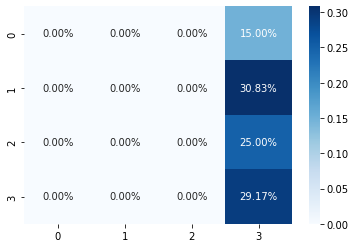

In [ ]:
cf_matrix = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')

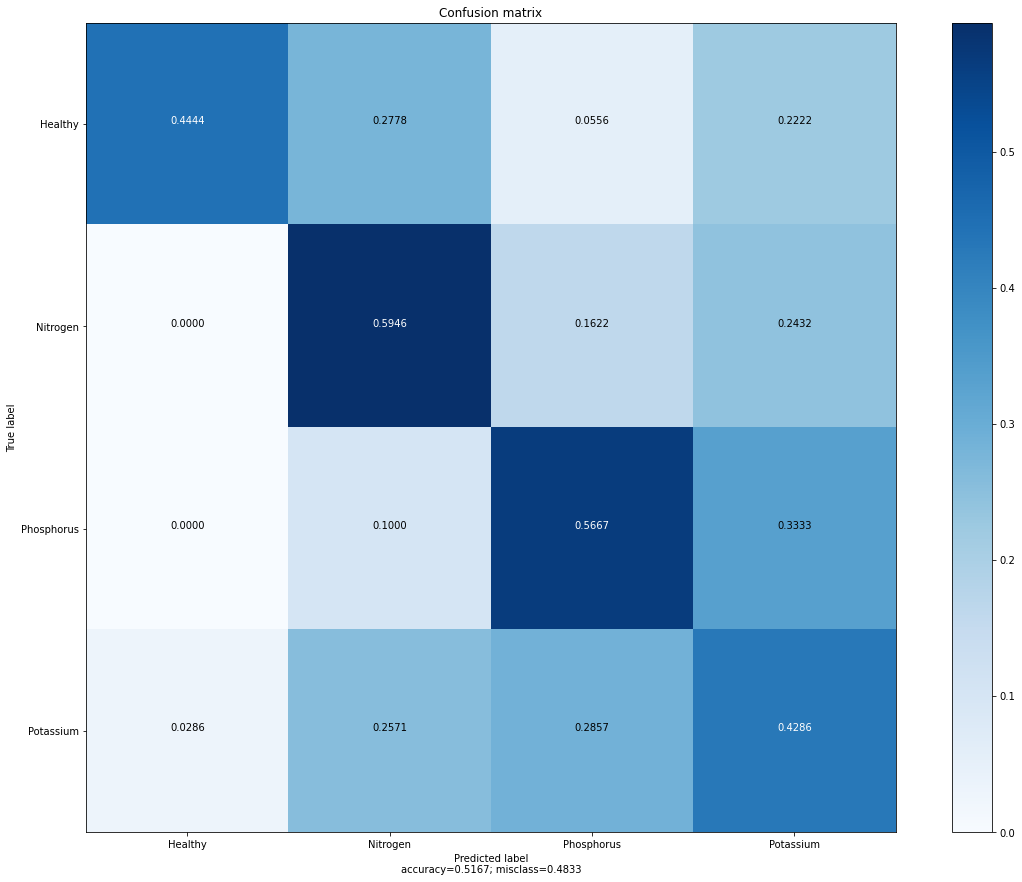

In [ ]:
plot_confusion_matrix(confusion_matrix(Y_test, Y_pred),target_names=valDefData.class_names)

print(Y_train)
print(Y_test)

##RBN Cross Train

In [ ]:
base_flowers_model = tf.keras.models.load_model('/content/gdrive/MyDrive/Backups/NPK/model_Basic_Transfer_0.6167.h5')

In [ ]:
import numpy as np
np.random.seed(128)  # for reproducibility
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

In [ ]:
DBN_Input_Convert = tf.keras.Model(inputs=base_flowers_model.inputs,
                           outputs=base_flowers_model.layers[4].output)

In [ ]:
DBN_Input_Convert.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6_input (InputLayer)  [(None, 256, 256, 3)]    0         
                                                                 
 conv2d_6 (Conv2D)           (None, 248, 248, 256)     62464     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 27, 27, 256)      0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 19, 19, 32)        663584    
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 2, 2, 32)         0         
 2D)                                                             
                                                                 
 flatten_3 (Flatten)         (None, 128)               0     

In [ ]:
DBN_Train_Input = DBN_Input_Convert.predict(def_train_imgs)
DBN_Val_Input = DBN_Input_Convert.predict(def_val_imgs)

In [ ]:
np.savetxt('train_DBN',DBN_Train_Input)

In [ ]:
np.savetxt('test_DBN',DBN_Val_Input)

In [ ]:
DBN_Train_Input.shape

(608, 128)

In [ ]:
#creating instance of one-hot-encoder
encoder = OneHotEncoder(handle_unknown='ignore')

#perform one-hot encoding on 'team' column
Y_train = encoder.fit_transform(def_train_labels.reshape(-1,1)).toarray()
Y_test = encoder.fit_transform(def_val_labels.reshape(-1,1)).toarray()
def_train_labels

In [ ]:
# Training
classifier = SupervisedDBNClassification(hidden_layers_structure=[128,128],
                                         learning_rate_rbm=0.00003,
                                         learning_rate=0.005,
                                         n_epochs_rbm=35,
                                         n_iter_backprop=200,
                                         batch_size=18,
                                         activation_function='relu',
                                         dropout_p=0.00)
classifier.fit(DBN_Train_Input, def_train_labels)

# Save the model
classifier.save('/content/gdrive/MyDrive/Backups/CNN_RBM_model2.pkl')

# Restore it
classifier = SupervisedDBNClassification.load('/content/gdrive/MyDrive/Backups/CNN_RBM_model2.pkl')

# Test
Y_pred = classifier.predict(DBN_Val_Input)
print('Done.\nAccuracy: %f' % accuracy_score(def_val_labels, Y_pred))

[START] Pre-training step:
>> Epoch 1 finished 	RBM Reconstruction error 489.419983
>> Epoch 2 finished 	RBM Reconstruction error 480.995575
>> Epoch 3 finished 	RBM Reconstruction error 464.218506
>> Epoch 4 finished 	RBM Reconstruction error 433.205994
>> Epoch 5 finished 	RBM Reconstruction error 385.215057
>> Epoch 6 finished 	RBM Reconstruction error 323.442230
>> Epoch 7 finished 	RBM Reconstruction error 256.367401
>> Epoch 8 finished 	RBM Reconstruction error 194.549744
>> Epoch 9 finished 	RBM Reconstruction error 148.641068
>> Epoch 10 finished 	RBM Reconstruction error 125.346756
>> Epoch 11 finished 	RBM Reconstruction error 126.706528
>> Epoch 12 finished 	RBM Reconstruction error 154.093719
>> Epoch 13 finished 	RBM Reconstruction error 207.447159
>> Epoch 14 finished 	RBM Reconstruction error 285.000153
>> Epoch 15 finished 	RBM Reconstruction error 384.181396
>> Epoch 16 finished 	RBM Reconstruction error 502.746765
>> Epoch 17 finished 	RBM Reconstruction error 637.476

In [ ]:
# Restore it
classifier = SupervisedDBNClassification.load('/content/gdrive/MyDrive/Backups/CNN_RBM_model3.pkl')

# Test
Y_pred = classifier.predict(DBN_Val_Input)
print('Done.\nAccuracy: %f' % accuracy_score(def_val_labels, Y_pred))

Done.
Accuracy: 0.741667


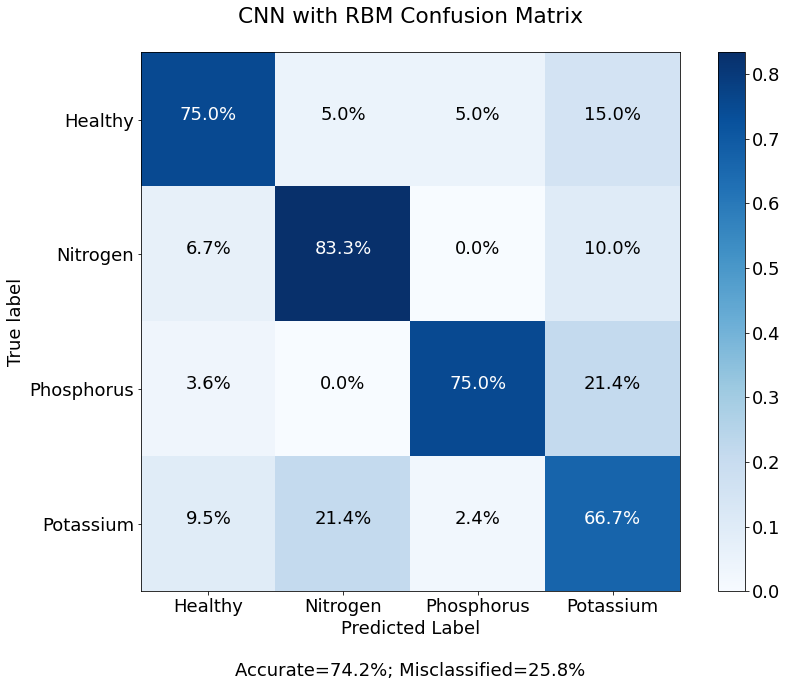

In [ ]:
plot_confusion_matrix(confusion_matrix(def_val_labels, Y_pred),target_names=valDefData.class_names,title='CNN with RBM Confusion Matrix\n')

In [ ]:
# Training
classifier = SupervisedDBNClassification(hidden_layers_structure=[128,128],
                                         learning_rate_rbm=0.00003,
                                         learning_rate=0.005,
                                         n_epochs_rbm=15,
                                         n_iter_backprop=200,
                                         batch_size=18,
                                         activation_function='relu',
                                         dropout_p=0.00)
classifier.fit(DBN_Train_Input, def_train_labels)

# Save the model
classifier.save('/content/gdrive/MyDrive/Backups/CNN_RBM_model.pkl')

# Restore it
classifier = SupervisedDBNClassification.load('model.pkl')

# Test
Y_pred = classifier.predict(DBN_Val_Input)
print('Done.\nAccuracy: %f' % accuracy_score(def_val_labels, Y_pred))

[START] Pre-training step:
>> Epoch 1 finished 	RBM Reconstruction error 0.191980
>> Epoch 2 finished 	RBM Reconstruction error 0.172051
>> Epoch 3 finished 	RBM Reconstruction error 0.170183
>> Epoch 4 finished 	RBM Reconstruction error 0.169385
>> Epoch 5 finished 	RBM Reconstruction error 0.168341
>> Epoch 6 finished 	RBM Reconstruction error 0.168240
>> Epoch 7 finished 	RBM Reconstruction error 0.167988
>> Epoch 8 finished 	RBM Reconstruction error 0.167799
>> Epoch 9 finished 	RBM Reconstruction error 0.166703
>> Epoch 10 finished 	RBM Reconstruction error 0.165286
>> Epoch 11 finished 	RBM Reconstruction error 0.164924
>> Epoch 12 finished 	RBM Reconstruction error 0.163514
>> Epoch 13 finished 	RBM Reconstruction error 0.161742
>> Epoch 14 finished 	RBM Reconstruction error 0.160963
>> Epoch 15 finished 	RBM Reconstruction error 0.159361
>> Epoch 16 finished 	RBM Reconstruction error 0.159385
>> Epoch 17 finished 	RBM Reconstruction error 0.157154
>> Epoch 18 finished 	RBM Reco

In [ ]:
CNN_RBM_classifier = SupervisedDBNClassification.load('/content/gdrive/MyDrive/Backups/CNN_RBM_model.pkl')

In [ ]:
Y_pred_CNN_RBM = classifier.predict(DBN_Val_Input)
confus = tf.math.confusion_matrix(def_val_labels,Y_pred)
print(confus)

Tensor("confusion_matrix_1/ScatterNd:0", shape=(4, 4), dtype=int32)


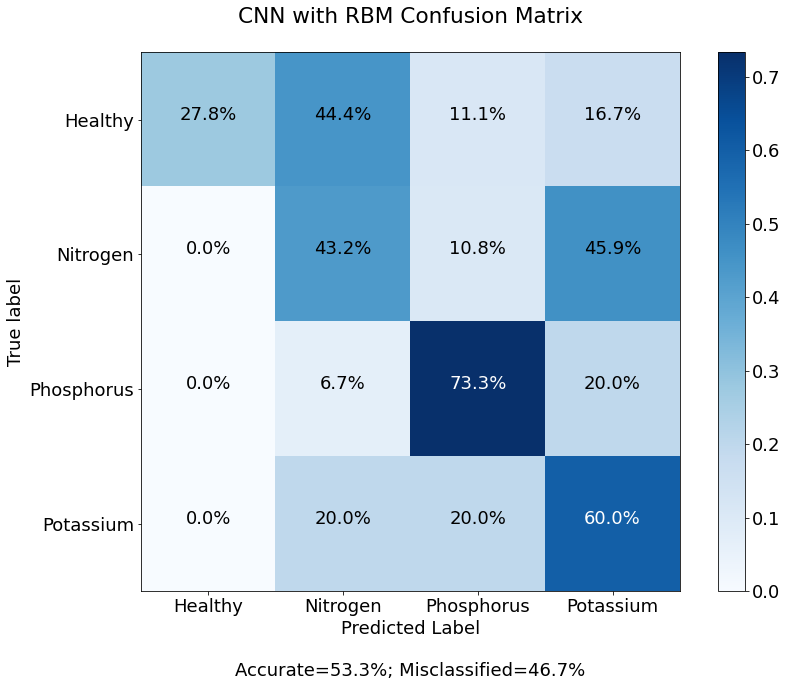

In [ ]:
plot_confusion_matrix(confusion_matrix(def_val_labels, Y_pred_CNN_RBM),target_names=valDefData.class_names,title='CNN with RBM Confusion Matrix\n')

#TFLite conversion

In [ ]:
model = tf.keras.models.load_model('/content/gdrive/MyDrive/Backups/NPK/model_0.6364.h5')

In [ ]:
model.make_predict_function()


In [ ]:
#import tf.lite.TFLiteConverter as tfConverter

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tfLiteModel = converter.convert()

with open('/content/gdrive/MyDrive/Backups/TFLite/NPK_Model4.tflite', 'wb') as f:
  f.write(tfLiteModel)

Example of model run via simulated android device correctly identifying a nitrogen deficient leaf:

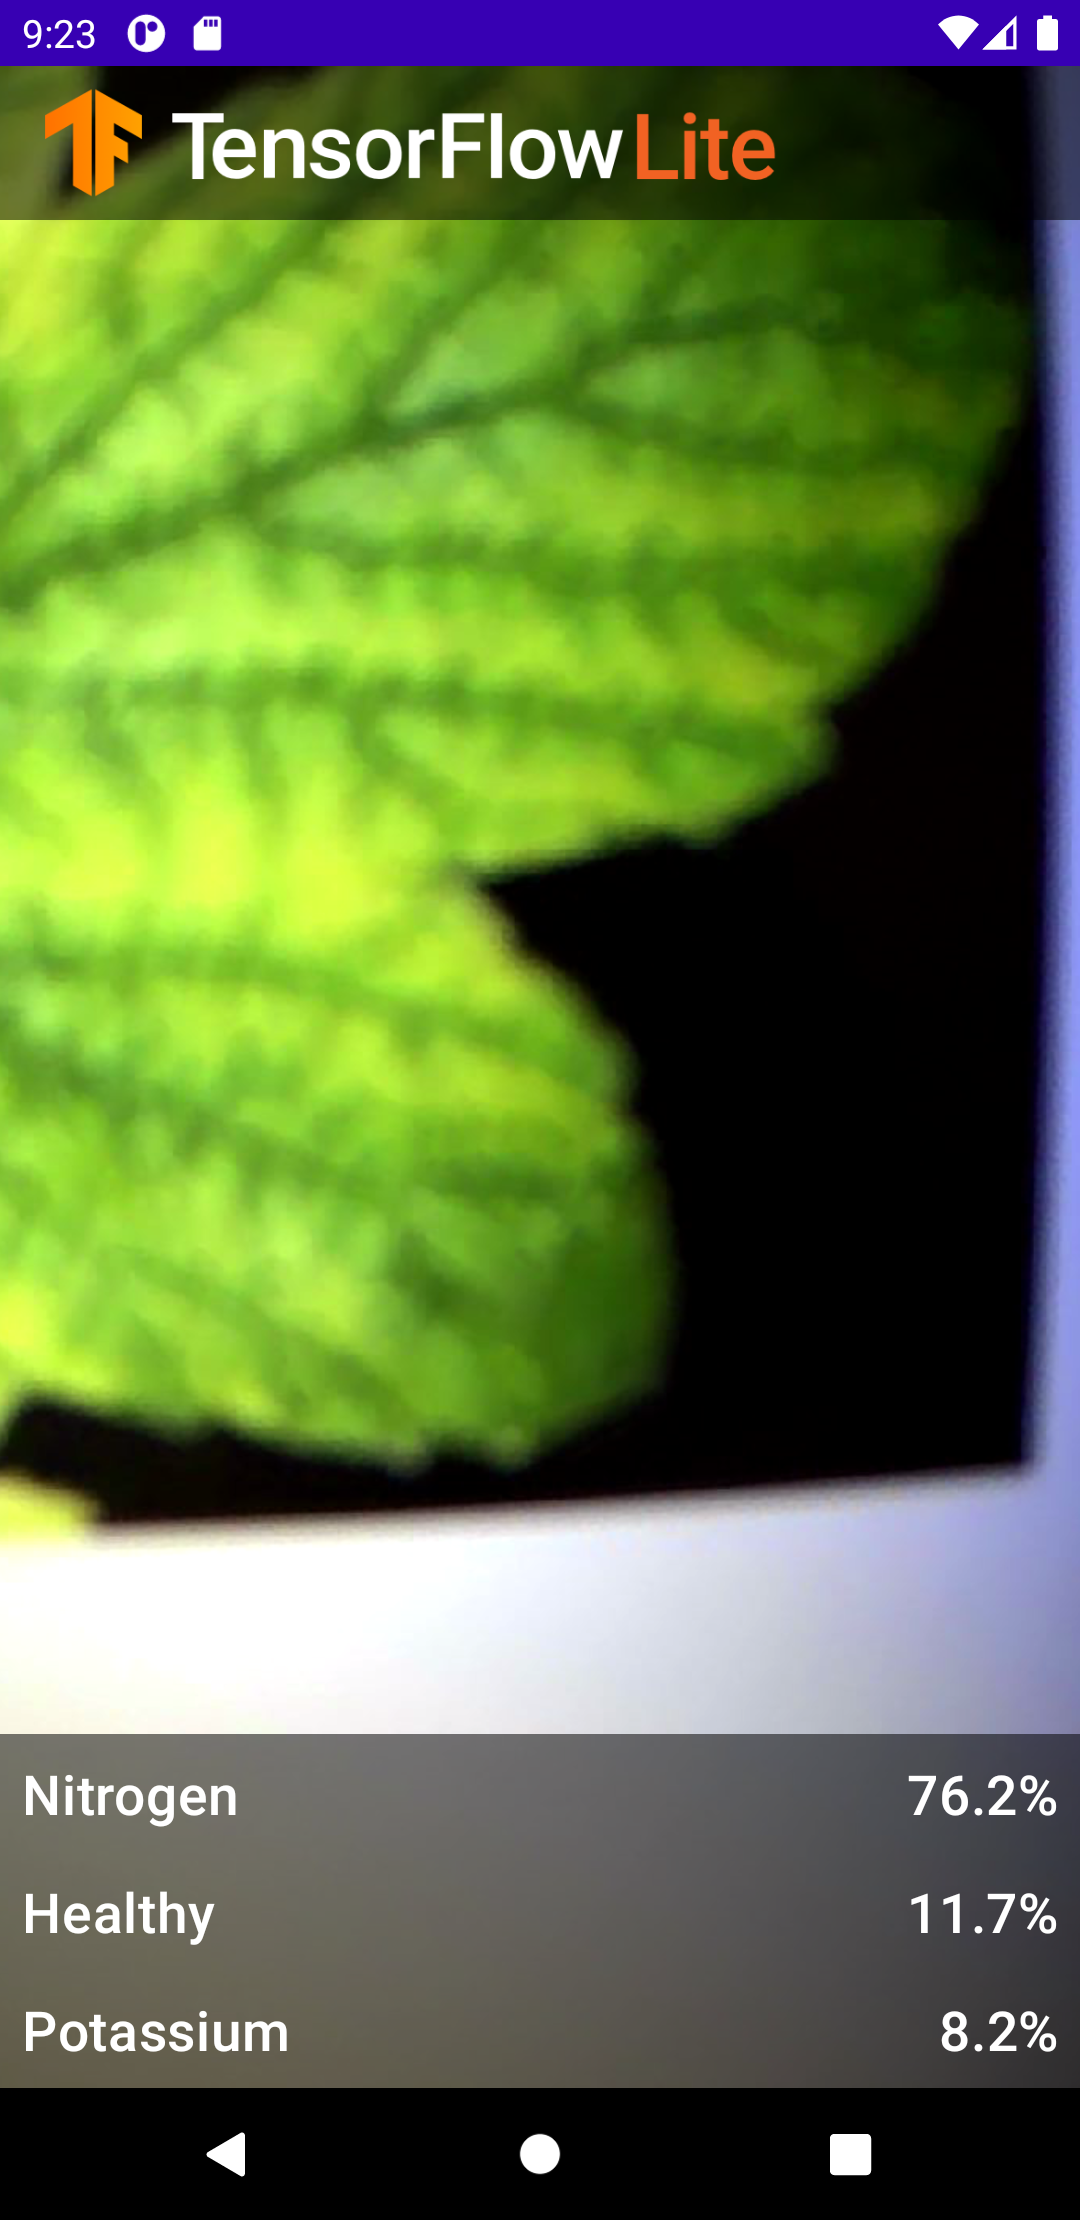

#Conclusions

Results:  The best performing model to estimate NPK deficiencies was built by utilizing a model initially built off the imagenet CNN and then re-trained to better classify flowers on a large dataset.  After being retrained to distinguish flowers the model was re-trained on NPK deficiencies.

Benefits of Transfer Learning:
Flowers basic CNN -> imagenet
  There was a significant improvement on the ability to classify flowers via utilization of the imagenet model.  Establishing the framework via the imagenet base model improved validation accuracy by approximately 50%

NPK Model based on ImageNet -> NPK Model based on Flowers Model
  An improvement was seen on the model in terms of validation accuracy, but a much larger imrpovement was seen on training time.  The model set to train on the model initially built on the flowers dataset quickly tied to, and then overfit the NPK dataset.  The model built without filters pre-designed for flowers took much longer to run, and additionally performed slightly worse in terms of validation accuracy



---
Areas for improvement:
Data:  The primary area for improvement on this dataset would be expanding the dataset.  Due to the time consuming nature of hand selecting images, and the need to remove many INPI images which were extremely unclear the dataset was fairly limited in it's capacity.
